In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [34]:
# Cargar el dataset desde la carpeta data/
df = pd.read_csv('data/Data_Set.csv')

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeras 5 filas:")
df.head()

Dataset cargado: 1000 filas × 13 columnas

Columnas: ['ID_Empleado', 'Edad', 'Antiguedad_Anios', 'Departamento', 'Nivel_Salarial_USD', 'Compa_Ratio', 'Distancia_Oficina_KM', 'Horas_Extra_Mes', 'Meses_Desde_Ascenso', 'Dias_Vacaciones_Tomados_12M', 'Evaluacion_Desempeno', 'Indice_Satisfaccion', 'Fuga']

Primeras 5 filas:


,ID_Empleado,Edad,Antiguedad_Anios,Departamento,Nivel_Salarial_USD,Compa_Ratio,Distancia_Oficina_KM,Horas_Extra_Mes,Meses_Desde_Ascenso,Dias_Vacaciones_Tomados_12M,Evaluacion_Desempeno,Indice_Satisfaccion,Fuga
0,E0001,44,11,Operations,6900,1.30,1,51,10,15,4,2,0
1,E0002,38,2,IT,5150,1.04,38,53,12,0,5,1,1
2,E0003,46,4,IT,6700,1.05,17,11,26,18,5,3,0
3,E0004,55,4,Sales,4800,0.87,2,23,19,9,1,2,1
4,E0005,37,17,IT,8000,0.86,38,37,9,8,4,2,0


In [35]:
# Información del dataset
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print(f"\n=== VALORES NULOS ===")
print(df.isnull().sum())
print("\n=== FILAS DUPLICADAS ===")
print(f"Duplicados : {df.duplicated().sum()}")
print(f"\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().round(2)

=== TIPOS DE DATOS ===
ID_Empleado                        str
Edad                             int64
Antiguedad_Anios                 int64
Departamento                       str
Nivel_Salarial_USD               int64
Compa_Ratio                    float64
Distancia_Oficina_KM             int64
Horas_Extra_Mes                  int64
Meses_Desde_Ascenso              int64
Dias_Vacaciones_Tomados_12M      int64
Evaluacion_Desempeno             int64
Indice_Satisfaccion              int64
Fuga                             int64
dtype: object

=== VALORES NULOS ===
ID_Empleado                    0
Edad                           0
Antiguedad_Anios               0
Departamento                   0
Nivel_Salarial_USD             0
Compa_Ratio                    0
Distancia_Oficina_KM           0
Horas_Extra_Mes                0
Meses_Desde_Ascenso            0
Dias_Vacaciones_Tomados_12M    0
Evaluacion_Desempeno           0
Indice_Satisfaccion            0
Fuga                           0
dtyp

,Edad,Antiguedad_Anios,Nivel_Salarial_USD,Compa_Ratio,Distancia_Oficina_KM,Horas_Extra_Mes,Meses_Desde_Ascenso,Dias_Vacaciones_Tomados_12M,Evaluacion_Desempeno,Indice_Satisfaccion,Fuga
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,39.70,4.87,4873.35,1.02,24.10,25.16,21.77,9.57,3.38,2.97,0.19
std,9.34,3.43,1654.61,0.22,11.36,16.73,14.58,7.10,0.99,1.08,0.40
min,22.00,0.00,1500.00,0.65,1.00,0.00,0.00,0.00,1.00,1.00,0.00
25%,33.00,3.00,3600.00,0.84,15.00,10.00,9.00,3.75,3.00,2.00,0.00
50%,40.00,4.00,4700.00,1.01,24.00,23.00,20.00,9.00,3.00,3.00,0.00
75%,46.00,6.00,5912.50,1.19,36.00,34.00,34.00,15.00,4.00,4.00,0.00
max,60.00,19.00,8000.00,1.35,40.00,55.00,48.00,28.00,5.00,5.00,1.00


In [36]:
# 1. Guardamos el resumen estadístico en una variable
resumen = df.describe()

# 2. Extraemos la media y el percentil 50 (mediana)
media = resumen.loc['mean']
mediana = resumen.loc['50%']

# 3. Calculamos la diferencia absoluta y el porcentaje de diferencia
diferencia_absoluta = (media - mediana).abs()
porcentaje_dif = ((diferencia_absoluta / media) * 100).round(2)

# 4. Creamos una tabla limpia para ver los resultados
analisis_simetria = pd.DataFrame({
    'Media': media.round(2),
    'Mediana (50%)': mediana.round(2),
    'Dif Absoluta': diferencia_absoluta.round(2),
    'Porcentaje Dif (%)': porcentaje_dif
})

print(analisis_simetria)

                               Media  Mediana (50%)  Dif Absoluta  \
Edad                           39.70          40.00          0.30   
Antiguedad_Anios                4.87           4.00          0.87   
Nivel_Salarial_USD           4873.35        4700.00        173.35   
Compa_Ratio                     1.02           1.01          0.01   
Distancia_Oficina_KM           24.10          24.00          0.10   
Horas_Extra_Mes                25.16          23.00          2.16   
Meses_Desde_Ascenso            21.77          20.00          1.77   
Dias_Vacaciones_Tomados_12M     9.57           9.00          0.57   
Evaluacion_Desempeno            3.38           3.00          0.38   
Indice_Satisfaccion             2.97           3.00          0.03   
Fuga                            0.19           0.00          0.19   

                             Porcentaje Dif (%)  
Edad                                       0.75  
Antiguedad_Anios                          17.93  
Nivel_Salarial_USD   

=== DISTRIBUCION DE FUGA ===
Se quedan (0): 806 empleados (80.6%)
Se fugan  (1): 194 empleados (19.4%)


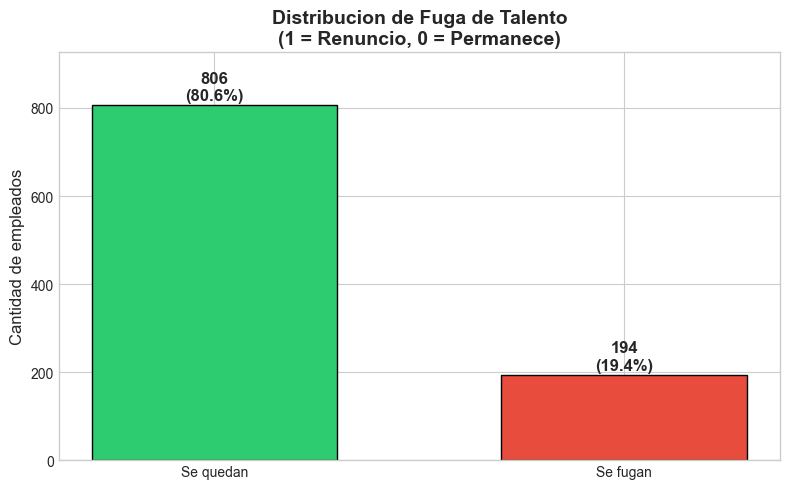

In [37]:
# Distribución de la variable target
fuga_counts = df['Fuga'].value_counts().sort_index()
fuga_pct = df['Fuga'].value_counts(normalize=True).sort_index() * 100

print("=== DISTRIBUCION DE FUGA ===")
print(f"Se quedan (0): {fuga_counts[0]} empleados ({fuga_pct[0]:.1f}%)")
print(f"Se fugan  (1): {fuga_counts[1]} empleados ({fuga_pct[1]:.1f}%)")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['Se quedan', 'Se fugan'], fuga_counts.values, color=colors, edgecolor='black', width=0.6)

# Valores sobre las barras
for bar, count, pct in zip(bars, fuga_counts.values, fuga_pct.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Cantidad de empleados', fontsize=12)
ax.set_title('Distribucion de Fuga de Talento\n(1 = Renuncio, 0 = Permanece)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(fuga_counts.values) * 1.15)

plt.tight_layout()
plt.show()

=== FUGA POR DEPARTAMENTO ===
Promedio global del dataset: 19.4%



,Total,Fugas,Tasa_Fuga,Tasa_Fuga_Pct
Departamento,,,,
HR,97,26,0.268,26.8
R&D,264,54,0.205,20.5
Operations,206,39,0.189,18.9
IT,131,23,0.176,17.6
Sales,302,52,0.172,17.2


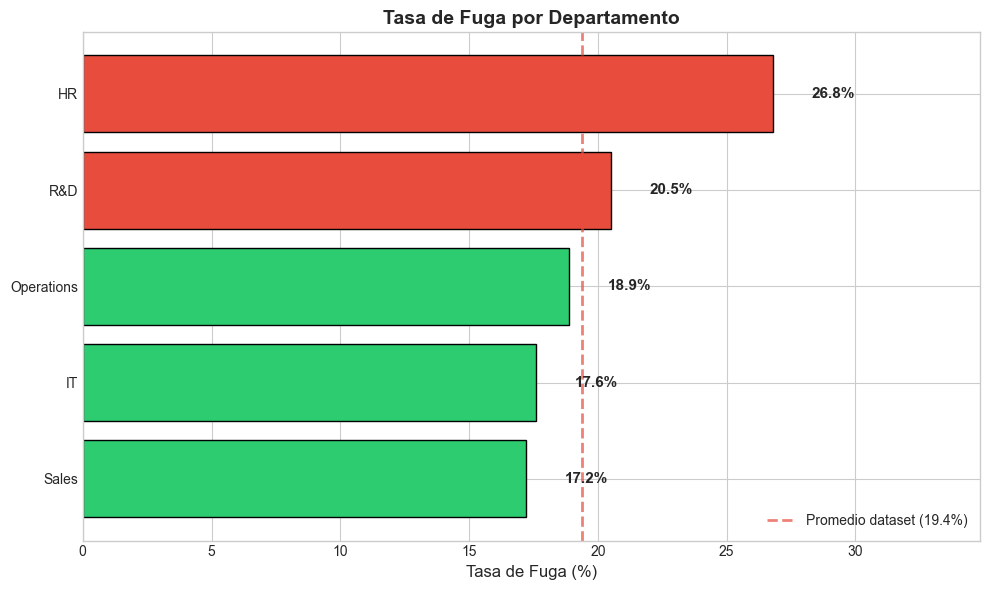

In [38]:
# Fuga por Departamento - leyenda abajo a la derecha

fuga_dept = df.groupby('Departamento')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_dept.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_dept['Tasa_Fuga_Pct'] = (fuga_dept['Tasa_Fuga'] * 100).round(1)

promedio_global = df['Fuga'].mean() * 100

print("=== FUGA POR DEPARTAMENTO ===")
print(f"Promedio global del dataset: {promedio_global:.1f}%")
print()
display(fuga_dept.sort_values('Tasa_Fuga', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
dept_sorted = fuga_dept.sort_values('Tasa_Fuga', ascending=True)

colors = ['#e74c3c' if x > promedio_global / 100 else '#2ecc71' for x in dept_sorted['Tasa_Fuga']]
bars = ax.barh(dept_sorted.index, dept_sorted['Tasa_Fuga_Pct'], color=colors, edgecolor='black')

for bar, pct in zip(bars, dept_sorted['Tasa_Fuga_Pct']):
    width = bar.get_width()
    ax.text(width + 1.5, bar.get_y() + bar.get_height()/2.,
            f'{pct}%', ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Tasa de Fuga (%)', fontsize=12)
ax.set_title('Tasa de Fuga por Departamento', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(dept_sorted['Tasa_Fuga_Pct']) * 1.3)

ax.axvline(x=promedio_global, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.7, 
           label=f'Promedio dataset ({promedio_global:.1f}%)')
# LEYENDA ABAJO A LA DERECHA
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

=== FUGA POR RANGO DE EDAD ===


,Total,Fugas,Tasa_Fuga,Tasa_Fuga_Pct
Rango_Edad,,,,
<<28,125,39,0.312,31.2
28-35,226,43,0.190,19.0
35-45,375,67,0.179,17.9
45-55,218,38,0.174,17.4
>55,56,7,0.125,12.5


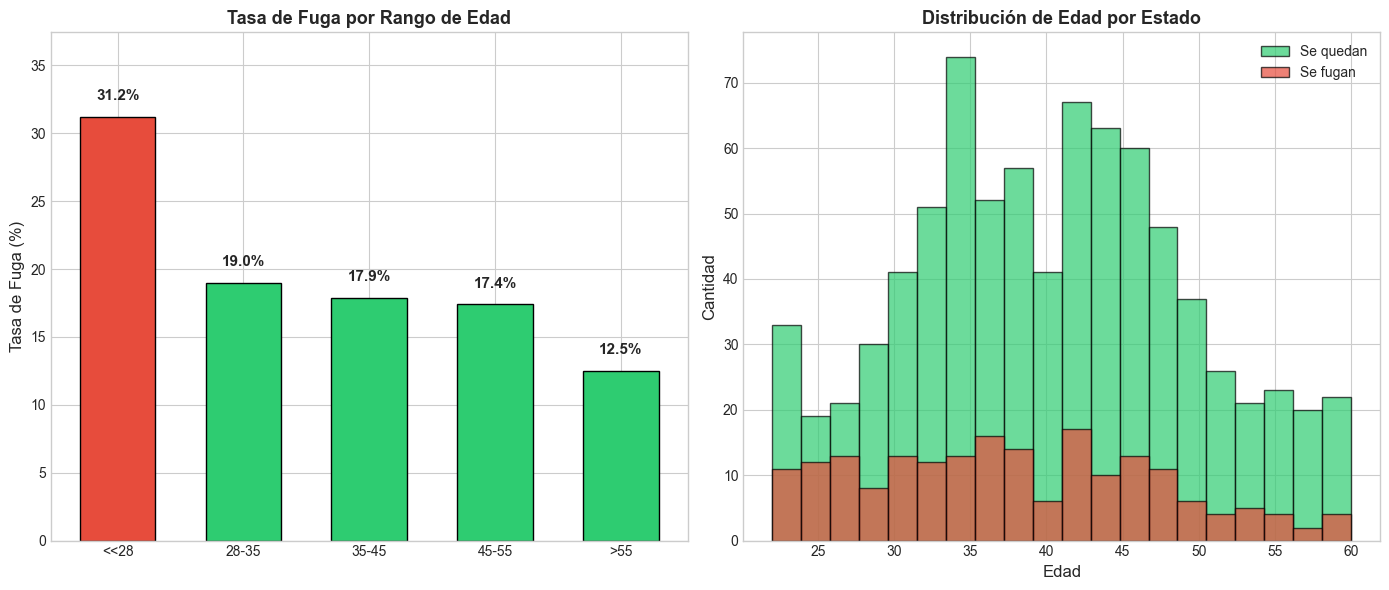


Correlación Edad-Fuga: -0.103
Edad promedio de los que se fugan: 37.7 años
Edad promedio de los que se quedan: 40.2 años


In [39]:
# Fuga por edad - análisis de rangos
df['Rango_Edad'] = pd.cut(df['Edad'], 
                          bins=[20, 28, 35, 45, 55, 65], 
                          labels=['<<28', '28-35', '35-45', '45-55', '>55'])

fuga_edad = df.groupby('Rango_Edad')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_edad.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_edad['Tasa_Fuga_Pct'] = (fuga_edad['Tasa_Fuga'] * 100).round(1)

print("=== FUGA POR RANGO DE EDAD ===")
display(fuga_edad)

# Gráfico de barras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: Tasa de fuga por rango
colors = ['#e74c3c' if x > 0.30 else '#f39c12' if x > 0.20 else '#2ecc71' for x in fuga_edad['Tasa_Fuga']]
bars1 = ax1.bar(fuga_edad.index, fuga_edad['Tasa_Fuga_Pct'], color=colors, edgecolor='black', width=0.6)

for bar, pct in zip(bars1, fuga_edad['Tasa_Fuga_Pct']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('Tasa de Fuga (%)', fontsize=12)
ax1.set_title('Tasa de Fuga por Rango de Edad', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(fuga_edad['Tasa_Fuga_Pct']) * 1.2)

# Derecha: Distribución de edad (histograma coloreado por fuga)
se_quedan = df[df['Fuga'] == 0]['Edad']
se_fugan = df[df['Fuga'] == 1]['Edad']

ax2.hist(se_quedan, bins=20, alpha=0.7, label='Se quedan', color='#2ecc71', edgecolor='black')
ax2.hist(se_fugan, bins=20, alpha=0.7, label='Se fugan', color='#e74c3c', edgecolor='black')

ax2.set_xlabel('Edad', fontsize=12)
ax2.set_ylabel('Cantidad', fontsize=12)
ax2.set_title('Distribución de Edad por Estado', fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# Estadística adicional: correlación
print(f"\nCorrelación Edad-Fuga: {df['Edad'].corr(df['Fuga']):.3f}")
print(f"Edad promedio de los que se fugan: {df[df['Fuga']==1]['Edad'].mean():.1f} años")
print(f"Edad promedio de los que se quedan: {df[df['Fuga']==0]['Edad'].mean():.1f} años")

=== FUGA POR EVALUACION DE DESEMPENO ===


,Total,Fugas,Tasa_Fuga,Tasa_Fuga_Pct
Evaluacion_Desempeno,,,,
1,43,11,0.256,25.6
2,135,31,0.230,23.0
3,332,60,0.181,18.1
4,381,68,0.178,17.8
5,109,24,0.220,22.0


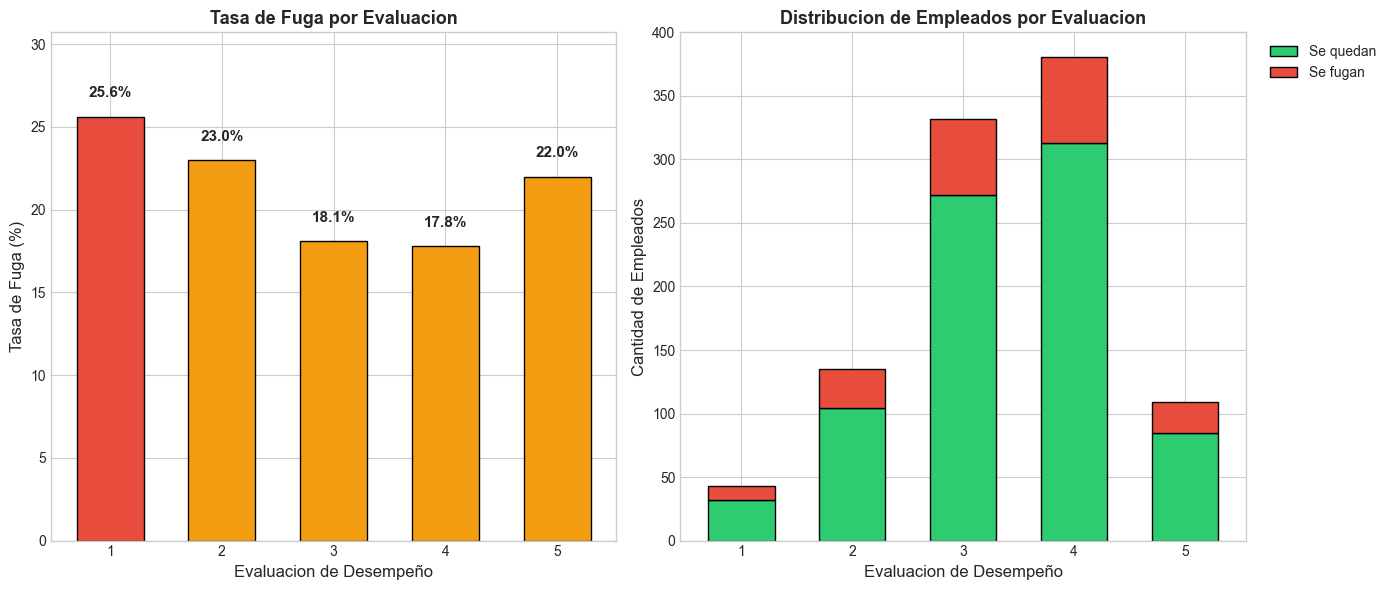


=== ESTRELLAS (Evaluacion 5) ===
Total: 109 empleados
Fugas: 24 (22.0%)
Subpagadas (Compa<0.95): 47
Fuga de subpagadas: 29.8%


In [40]:
# Fuga por evaluación de desempeño
fuga_eval = df.groupby('Evaluacion_Desempeno')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_eval.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_eval['Tasa_Fuga_Pct'] = (fuga_eval['Tasa_Fuga'] * 100).round(1)

print("=== FUGA POR EVALUACION DE DESEMPENO ===")
display(fuga_eval)

# Gráfico de barras agrupadas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: Tasa de fuga por evaluación
colors = ['#e74c3c' if x > 0.25 else '#f39c12' if x > 0.15 else '#2ecc71' for x in fuga_eval['Tasa_Fuga']]
bars1 = ax1.bar(fuga_eval.index, fuga_eval['Tasa_Fuga_Pct'], color=colors, edgecolor='black', width=0.6)

for bar, pct in zip(bars1, fuga_eval['Tasa_Fuga_Pct']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Evaluacion de Desempeño', fontsize=12)
ax1.set_ylabel('Tasa de Fuga (%)', fontsize=12)
ax1.set_title('Tasa de Fuga por Evaluacion', fontsize=13, fontweight='bold')
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_ylim(0, max(fuga_eval['Tasa_Fuga_Pct']) * 1.2)

# Derecha: Distribución de evaluaciones (apilado por fuga)
eval_counts = pd.crosstab(df['Evaluacion_Desempeno'], df['Fuga'])
eval_counts.plot(kind='bar', stacked=True, ax=ax2, color=['#2ecc71', '#e74c3c'], 
                 edgecolor='black', width=0.6)

ax2.set_xlabel('Evaluacion de Desempeño', fontsize=12)
ax2.set_ylabel('Cantidad de Empleados', fontsize=12)
ax2.set_title('Distribucion de Empleados por Evaluacion', fontsize=13, fontweight='bold')
ax2.legend(['Se quedan', 'Se fugan'], loc='upper left', bbox_to_anchor=(1.02, 1))
ax2.set_xticklabels([1, 2, 3, 4, 5], rotation=0)

plt.tight_layout()
plt.show()

# Hallazgo específico: estrellas que se van
estrellas = df[df['Evaluacion_Desempeno'] == 5]
print(f"\n=== ESTRELLAS (Evaluacion 5) ===")
print(f"Total: {len(estrellas)} empleados")
print(f"Fugas: {estrellas['Fuga'].sum()} ({estrellas['Fuga'].mean():.1%})")
print(f"Subpagadas (Compa<0.95): {len(estrellas[estrellas['Compa_Ratio'] < 0.95])}")
print(f"Fuga de subpagadas: {estrellas[estrellas['Compa_Ratio'] < 0.95]['Fuga'].mean():.1%}")

=== FUGA POR INDICE DE SATISFACCION ===


,Total,Fugas,Tasa_Fuga,Tasa_Fuga_Pct
Indice_Satisfaccion,,,,
1,97,50,0.515,51.5
2,235,82,0.349,34.9
3,337,40,0.119,11.9
4,261,20,0.077,7.7
5,70,2,0.029,2.9


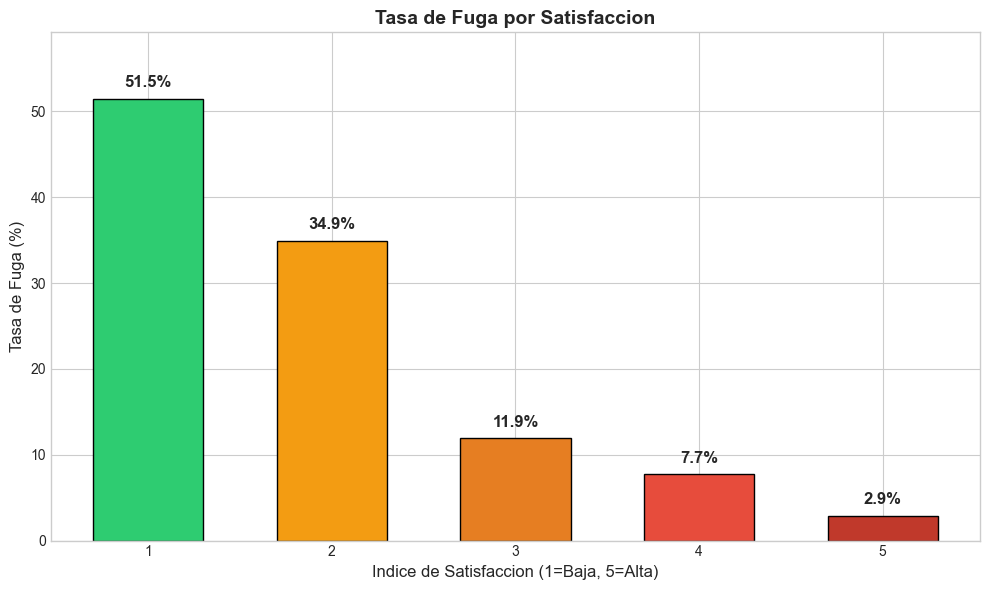


Correlacion Satisfaccion-Fuga: -0.358


In [41]:
# Fuga por satisfacción
fuga_sat = df.groupby('Indice_Satisfaccion')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_sat.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_sat['Tasa_Fuga_Pct'] = (fuga_sat['Tasa_Fuga'] * 100).round(1)

print("=== FUGA POR INDICE DE SATISFACCION ===")
display(fuga_sat)

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
bars = ax.bar(fuga_sat.index, fuga_sat['Tasa_Fuga_Pct'], color=colors, edgecolor='black', width=0.6)

for bar, pct in zip(bars, fuga_sat['Tasa_Fuga_Pct']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Indice de Satisfaccion (1=Baja, 5=Alta)', fontsize=12)
ax.set_ylabel('Tasa de Fuga (%)', fontsize=12)
ax.set_title('Tasa de Fuga por Satisfaccion', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(0, max(fuga_sat['Tasa_Fuga_Pct']) * 1.15)

plt.tight_layout()
plt.show()

print(f"\nCorrelacion Satisfaccion-Fuga: {df['Indice_Satisfaccion'].corr(df['Fuga']):.3f}")

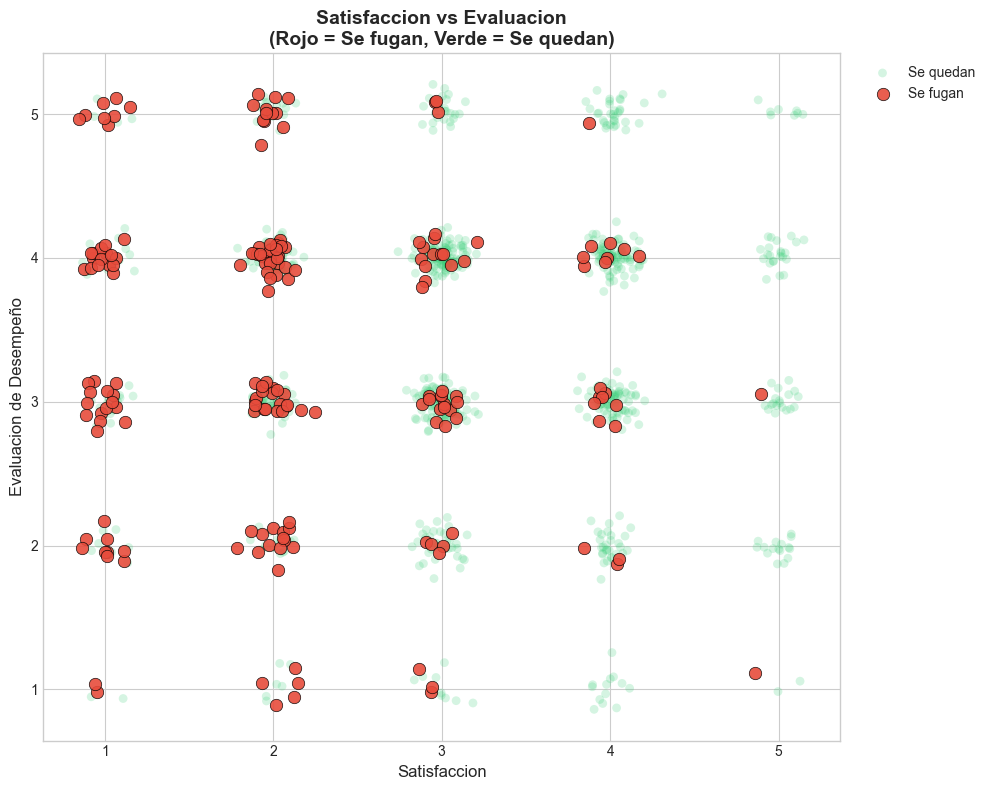


=== EMPLEADOS DESCONECTADOS (Eval>=4, Sat<=2) ===
Cantidad: 168 empleados
Fuga: 39.3%


In [42]:
# Scatter: Satisfacción vs Evaluación, coloreado por fuga
fig, ax = plt.subplots(figsize=(10, 8))

se_quedan = df['Fuga'] == 0
se_fugan = df['Fuga'] == 1

np.random.seed(42)
jitter_sat = df['Indice_Satisfaccion'] + np.random.normal(0, 0.08, len(df))
jitter_eval = df['Evaluacion_Desempeno'] + np.random.normal(0, 0.08, len(df))

ax.scatter(jitter_sat[se_quedan], jitter_eval[se_quedan], 
           alpha=0.2, c='#2ecc71', label='Se quedan', s=40, edgecolors='none')

ax.scatter(jitter_sat[se_fugan], jitter_eval[se_fugan], 
           alpha=0.9, c='#e74c3c', label='Se fugan', s=80, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Satisfaccion', fontsize=12)
ax.set_ylabel('Evaluacion de Desempeño', fontsize=12)
ax.set_title('Satisfaccion vs Evaluacion\n(Rojo = Se fugan, Verde = Se quedan)', 
             fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)

plt.tight_layout()
plt.show()

# Hallazgo: desconexion
desconectados = df[(df['Evaluacion_Desempeno'] >= 4) & (df['Indice_Satisfaccion'] <= 2)]
print(f"\n=== EMPLEADOS DESCONECTADOS (Eval>=4, Sat<=2) ===")
print(f"Cantidad: {len(desconectados)} empleados")
print(f"Fuga: {desconectados['Fuga'].mean():.1%}")

=== FUGA POR RANGO SALARIAL ===


,Total,Fugas,Tasa_Fuga,Tasa_Fuga_Pct
Rango_Salario,,,,
<2.5K,60,21,0.350,35.0
2.5-4K,281,82,0.292,29.2
4-5.5K,336,59,0.176,17.6
5.5-7K,185,19,0.103,10.3
>7K,138,13,0.094,9.4


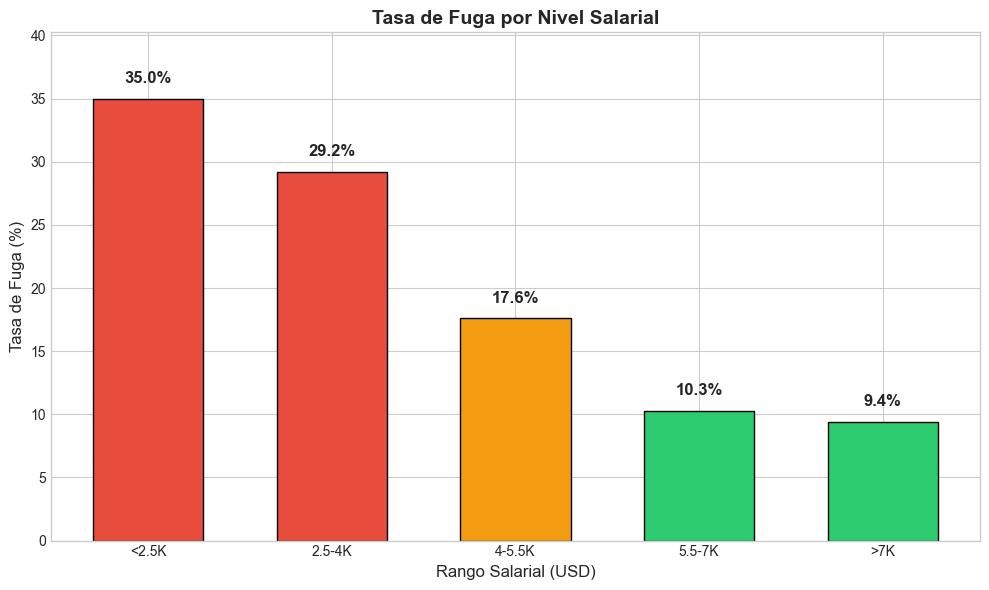


Correlacion Salario-Fuga: -0.208


In [43]:
# Fuga por nivel salarial (rangos)
df['Rango_Salario'] = pd.cut(df['Nivel_Salarial_USD'],
                             bins=[0, 2500, 4000, 5500, 7000, 9000],
                             labels=['<2.5K', '2.5-4K', '4-5.5K', '5.5-7K', '>7K'])

fuga_sal = df.groupby('Rango_Salario')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_sal.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_sal['Tasa_Fuga_Pct'] = (fuga_sal['Tasa_Fuga'] * 100).round(1)

print("=== FUGA POR RANGO SALARIAL ===")
display(fuga_sal)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if x > 0.25 else '#f39c12' if x > 0.15 else '#2ecc71' for x in fuga_sal['Tasa_Fuga']]
bars = ax.bar(fuga_sal.index, fuga_sal['Tasa_Fuga_Pct'], color=colors, edgecolor='black', width=0.6)

for bar, pct in zip(bars, fuga_sal['Tasa_Fuga_Pct']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Rango Salarial (USD)', fontsize=12)
ax.set_ylabel('Tasa de Fuga (%)', fontsize=12)
ax.set_title('Tasa de Fuga por Nivel Salarial', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(fuga_sal['Tasa_Fuga_Pct']) * 1.15)

plt.tight_layout()
plt.show()

print(f"\nCorrelacion Salario-Fuga: {df['Nivel_Salarial_USD'].corr(df['Fuga']):.3f}")

=== FUGA POR COMPA-RATIO (RANGOS DE NEGOCIO) ===


,Total,Fugas,Tasa_Fuga,Tasa_Fuga_Pct
Rango_Compa_Negocio,,,,
Crítico\n<0.80,196,65,0.332,33.2
Bajo\n0.80-0.95,217,47,0.217,21.7
Justo\n0.95-1.05,147,36,0.245,24.5
Alto\n1.05-1.20,199,19,0.095,9.5
Muy Alto\n>1.20,241,27,0.112,11.2


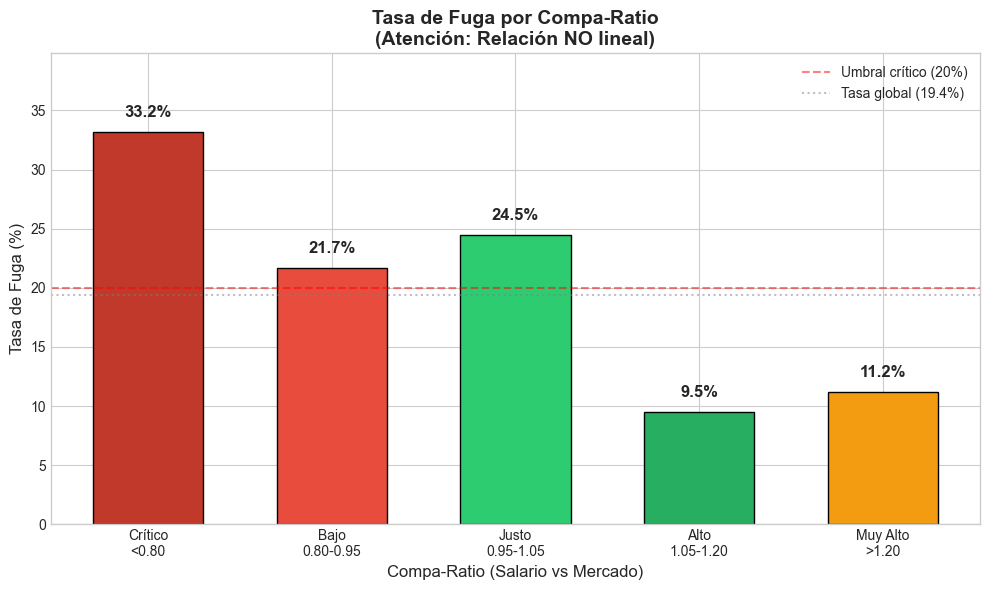


=== HALLAZGOS CLAVE ===
Críticos (<0.80): 186 empleados, fuga 34.9%
Justos (0.95-1.05): 164 empleados, fuga 22.0%
Muy altos (>1.20): 241 empleados, fuga 11.2%


In [44]:
# Fuga por compa-ratio con rangos de NEGOCIO (no estadísticos)
df['Rango_Compa_Negocio'] = pd.cut(df['Compa_Ratio'],
                                   bins=[0, 0.80, 0.95, 1.05, 1.20, 2],
                                   labels=['Crítico\n<0.80', 'Bajo\n0.80-0.95', 
                                           'Justo\n0.95-1.05', 'Alto\n1.05-1.20', 'Muy Alto\n>1.20'])

fuga_compa = df.groupby('Rango_Compa_Negocio')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_compa.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_compa['Tasa_Fuga_Pct'] = (fuga_compa['Tasa_Fuga'] * 100).round(1)

print("=== FUGA POR COMPA-RATIO (RANGOS DE NEGOCIO) ===")
display(fuga_compa)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#c0392b', '#e74c3c', '#2ecc71', '#27ae60', '#f39c12']
bars = ax.bar(fuga_compa.index, fuga_compa['Tasa_Fuga_Pct'], color=colors, edgecolor='black', width=0.6)

for bar, pct in zip(bars, fuga_compa['Tasa_Fuga_Pct']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Compa-Ratio (Salario vs Mercado)', fontsize=12)
ax.set_ylabel('Tasa de Fuga (%)', fontsize=12)
ax.set_title('Tasa de Fuga por Compa-Ratio\n(Atención: Relación NO lineal)', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(fuga_compa['Tasa_Fuga_Pct']) * 1.2)

# Líneas de referencia
ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Umbral crítico (20%)')
ax.axhline(y=df['Fuga'].mean()*100, color='gray', linestyle=':', alpha=0.5, label=f'Tasa global ({df["Fuga"].mean()*100:.1f}%)')
ax.legend()

plt.tight_layout()
plt.show()

# Hallazgo clave: comparar extremos
criticos = df[df['Compa_Ratio'] < 0.80]
muy_altos = df[df['Compa_Ratio'] > 1.20]
seguros = df[(df['Compa_Ratio'] >= 0.95) & (df['Compa_Ratio'] <= 1.05)]

print(f"\n=== HALLAZGOS CLAVE ===")
print(f"Críticos (<0.80): {len(criticos)} empleados, fuga {criticos['Fuga'].mean():.1%}")
print(f"Justos (0.95-1.05): {len(seguros)} empleados, fuga {seguros['Fuga'].mean():.1%}")
print(f"Muy altos (>1.20): {len(muy_altos)} empleados, fuga {muy_altos['Fuga'].mean():.1%}")

In [45]:
# Comparar el grupo "justo pero fugados" vs el grupo "seguro 1.07-1.21"
pico = df[(df['Compa_Ratio'] > 1.0) & (df['Compa_Ratio'] <= 1.07)]
seguros = df[(df['Compa_Ratio'] > 1.07) & (df['Compa_Ratio'] <= 1.21)]
bajos = df[df['Compa_Ratio'] < 0.80]

print("=== COMPARACIÓN DE GRUPOS ===\n")
for nombre, grupo in [("Pico 1.0-1.07", pico), ("Seguros 1.07-1.21", seguros), ("Críticos <0.80", bajos)]:
    print(f"{nombre} (n={len(grupo)}):")
    print(f"  Fuga: {grupo['Fuga'].mean():.1%}")
    print(f"  Satisfacción promedio: {grupo['Indice_Satisfaccion'].mean():.2f}")
    print(f"  Horas extra promedio: {grupo['Horas_Extra_Mes'].mean():.1f}")
    print(f"  Meses desde ascenso: {grupo['Meses_Desde_Ascenso'].mean():.1f}")
    print(f"  Evaluación promedio: {grupo['Evaluacion_Desempeno'].mean():.2f}")
    print(f"  Edad promedio: {grupo['Edad'].mean():.1f}")
    print()

=== COMPARACIÓN DE GRUPOS ===

Pico 1.0-1.07 (n=100):
  Fuga: 21.0%
  Satisfacción promedio: 2.87
  Horas extra promedio: 25.1
  Meses desde ascenso: 21.8
  Evaluación promedio: 3.45
  Edad promedio: 39.9

Seguros 1.07-1.21 (n=179):
  Fuga: 11.7%
  Satisfacción promedio: 2.95
  Horas extra promedio: 24.0
  Meses desde ascenso: 23.7
  Evaluación promedio: 3.49
  Edad promedio: 40.6

Críticos <0.80 (n=186):
  Fuga: 34.9%
  Satisfacción promedio: 2.93
  Horas extra promedio: 23.0
  Meses desde ascenso: 22.0
  Evaluación promedio: 3.17
  Edad promedio: 39.4



=== FUGA POR HORAS EXTRA ===


,Total,Fugas,Tasa_Fuga,Tasa_Fuga_Pct
Rango_HorasExtra,,,,
0-5\n(Bajo),129,15,0.116,11.6
6-15\n(Normal),205,24,0.117,11.7
16-25\n(Alto),241,38,0.158,15.8
26-35\n(Muy alto),180,51,0.283,28.3
>35\n(Extremo),245,66,0.269,26.9


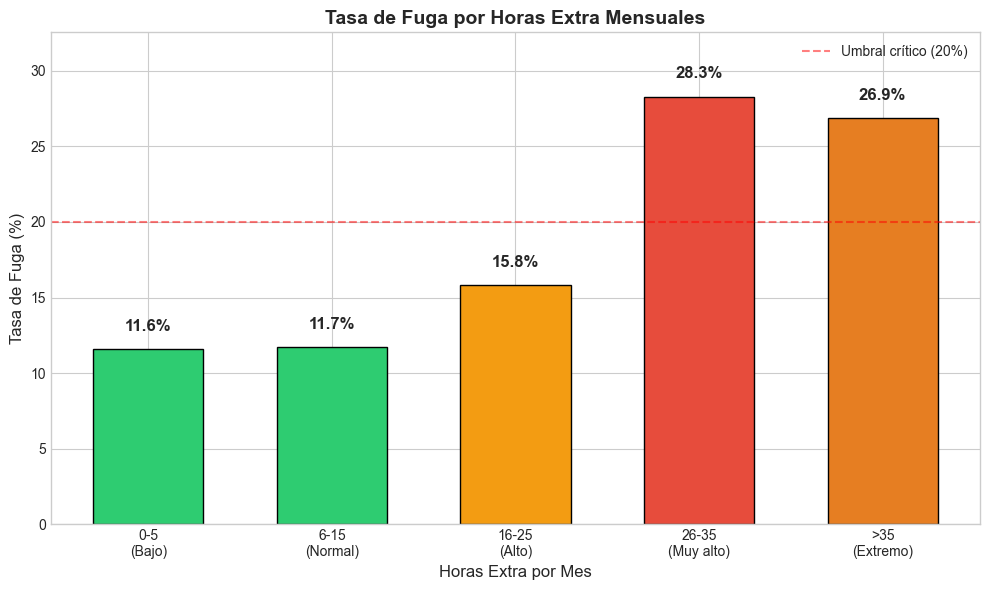


Correlacion HorasExtra-Fuga: 0.174


In [46]:
# Fuga por horas extra (rangos)
df['Rango_HorasExtra'] = pd.cut(df['Horas_Extra_Mes'],
                                bins=[-1, 5, 15, 25, 35, 100],
                                labels=['0-5\n(Bajo)', '6-15\n(Normal)', 
                                        '16-25\n(Alto)', '26-35\n(Muy alto)', '>35\n(Extremo)'])

fuga_he = df.groupby('Rango_HorasExtra')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_he.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_he['Tasa_Fuga_Pct'] = (fuga_he['Tasa_Fuga'] * 100).round(1)

print("=== FUGA POR HORAS EXTRA ===")
display(fuga_he)

# Gráfico con colores según MAGNITUD de riesgo (no posición)
fig, ax = plt.subplots(figsize=(10, 6))

tasa_valores = fuga_he['Tasa_Fuga'].values
colors = ['#2ecc71' if x < 0.12 else '#f39c12' if x < 0.20 else '#e67e22' if x < 0.28 else '#e74c3c' for x in tasa_valores]

bars = ax.bar(fuga_he.index, fuga_he['Tasa_Fuga_Pct'], color=colors, edgecolor='black', width=0.6)

for bar, pct in zip(bars, fuga_he['Tasa_Fuga_Pct']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Horas Extra por Mes', fontsize=12)
ax.set_ylabel('Tasa de Fuga (%)', fontsize=12)
ax.set_title('Tasa de Fuga por Horas Extra Mensuales', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(fuga_he['Tasa_Fuga_Pct']) * 1.15)

# Línea de referencia al 20%
ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Umbral crítico (20%)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nCorrelacion HorasExtra-Fuga: {df['Horas_Extra_Mes'].corr(df['Fuga']):.3f}")

=== FUGA POR VACACIONES TOMADAS (12M) ===


,Total,Fugas,Tasa_Fuga,Tasa_Fuga_Pct
Rango_Vacaciones,,,,
0-5\n(Casi nada),352,98,0.278,27.8
6-10\n(Poco),222,41,0.185,18.5
11-15\n(Normal),210,32,0.152,15.2
16-20\n(Bien),124,18,0.145,14.5
>20\n(Mucho),92,5,0.054,5.4


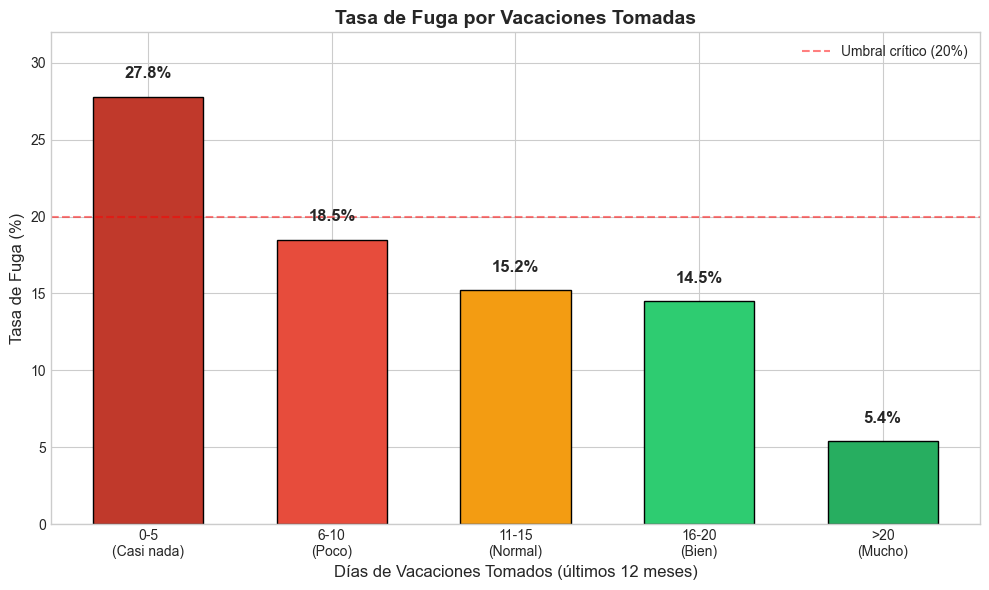


Correlacion Vacaciones-Fuga: -0.191


In [47]:
# Fuga por días de vacaciones tomados
df['Rango_Vacaciones'] = pd.cut(df['Dias_Vacaciones_Tomados_12M'],
                                bins=[-1, 5, 10, 15, 20, 30],
                                labels=['0-5\n(Casi nada)', '6-10\n(Poco)', 
                                        '11-15\n(Normal)', '16-20\n(Bien)', '>20\n(Mucho)'])

fuga_vac = df.groupby('Rango_Vacaciones')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_vac.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_vac['Tasa_Fuga_Pct'] = (fuga_vac['Tasa_Fuga'] * 100).round(1)

print("=== FUGA POR VACACIONES TOMADAS (12M) ===")
display(fuga_vac)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#c0392b', '#e74c3c', '#f39c12', '#2ecc71', '#27ae60']
bars = ax.bar(fuga_vac.index, fuga_vac['Tasa_Fuga_Pct'], color=colors, edgecolor='black', width=0.6)

for bar, pct in zip(bars, fuga_vac['Tasa_Fuga_Pct']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{pct}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Días de Vacaciones Tomados (últimos 12 meses)', fontsize=12)
ax.set_ylabel('Tasa de Fuga (%)', fontsize=12)
ax.set_title('Tasa de Fuga por Vacaciones Tomadas', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(fuga_vac['Tasa_Fuga_Pct']) * 1.15)

ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Umbral crítico (20%)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nCorrelacion Vacaciones-Fuga: {df['Dias_Vacaciones_Tomados_12M'].corr(df['Fuga']):.3f}")

=== COMBO CRÍTICO: HORAS EXTRA + VACACIONES ===

                  Total  Fugas  Tasa_Fuga  Tasa_Fuga_Pct
Burnout_Riesgo                                          
Crítico             337    102      0.303           30.3
Alto HE             232     40      0.172           17.2
Pocas vacaciones    199     29      0.146           14.6
Bajo                232     23      0.099            9.9


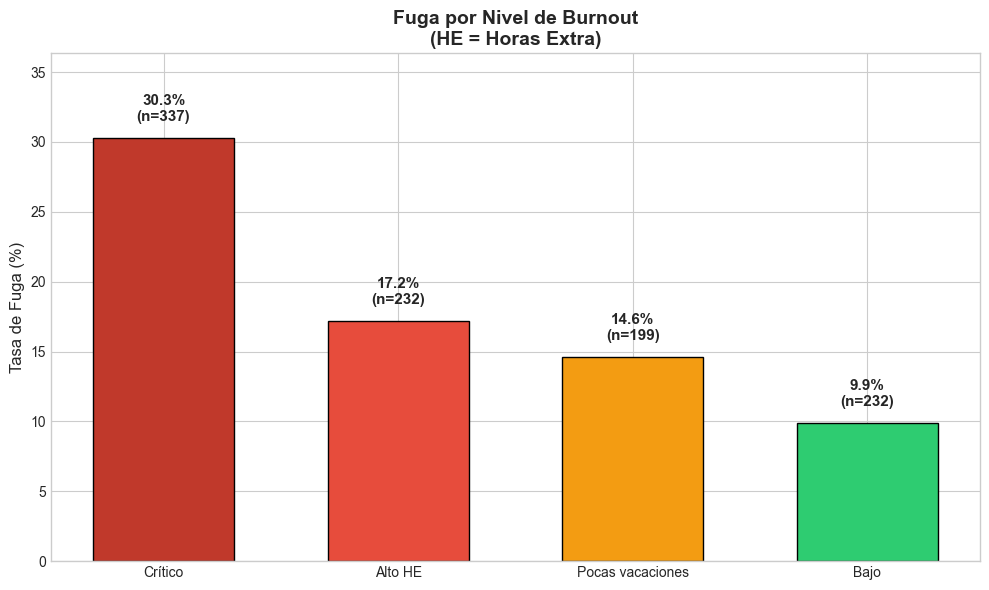


=== PERFIL DEL GRUPO CRÍTICO ===
Cantidad: 337 empleados (33.7% del total)
Fuga: 30.3%
Horas extra promedio: 37.6
Vacaciones promedio: 3.8
Satisfacción promedio: 2.78
Compa-Ratio promedio: 1.022


In [48]:
# Combo: Horas extra + Vacaciones
print("=== COMBO CRÍTICO: HORAS EXTRA + VACACIONES ===\n")

# Definir grupos de riesgo
df['Burnout_Riesgo'] = 'Bajo'
df.loc[(df['Horas_Extra_Mes'] > 20) & (df['Dias_Vacaciones_Tomados_12M'] < 10), 'Burnout_Riesgo'] = 'Crítico'
df.loc[(df['Horas_Extra_Mes'] > 20) & (df['Dias_Vacaciones_Tomados_12M'] >= 10), 'Burnout_Riesgo'] = 'Alto HE'
df.loc[(df['Horas_Extra_Mes'] <= 20) & (df['Dias_Vacaciones_Tomados_12M'] < 10), 'Burnout_Riesgo'] = 'Pocas vacaciones'

fuga_burnout = df.groupby('Burnout_Riesgo')['Fuga'].agg(['count', 'sum', 'mean']).round(3)
fuga_burnout.columns = ['Total', 'Fugas', 'Tasa_Fuga']
fuga_burnout['Tasa_Fuga_Pct'] = (fuga_burnout['Tasa_Fuga'] * 100).round(1)
fuga_burnout = fuga_burnout.sort_values('Tasa_Fuga', ascending=False)

print(fuga_burnout)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

orden = ['Crítico', 'Alto HE', 'Pocas vacaciones', 'Bajo']
colores = {'Crítico': '#c0392b', 'Alto HE': '#e74c3c', 'Pocas vacaciones': '#f39c12', 'Bajo': '#2ecc71'}

bars = ax.bar(orden, [fuga_burnout.loc[r, 'Tasa_Fuga_Pct'] for r in orden],
              color=[colores[r] for r in orden], edgecolor='black', width=0.6)

for bar, r in zip(bars, orden):
    height = bar.get_height()
    count = fuga_burnout.loc[r, 'Total']
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Tasa de Fuga (%)', fontsize=12)
ax.set_title('Fuga por Nivel de Burnout\n(HE = Horas Extra)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(fuga_burnout['Tasa_Fuga_Pct']) * 1.2)

plt.tight_layout()
plt.show()

# Hallazgo específico
criticos = df[df['Burnout_Riesgo'] == 'Crítico']
print(f"\n=== PERFIL DEL GRUPO CRÍTICO ===")
print(f"Cantidad: {len(criticos)} empleados ({len(criticos)/len(df)*100:.1f}% del total)")
print(f"Fuga: {criticos['Fuga'].mean():.1%}")
print(f"Horas extra promedio: {criticos['Horas_Extra_Mes'].mean():.1f}")
print(f"Vacaciones promedio: {criticos['Dias_Vacaciones_Tomados_12M'].mean():.1f}")
print(f"Satisfacción promedio: {criticos['Indice_Satisfaccion'].mean():.2f}")
print(f"Compa-Ratio promedio: {criticos['Compa_Ratio'].mean():.3f}")

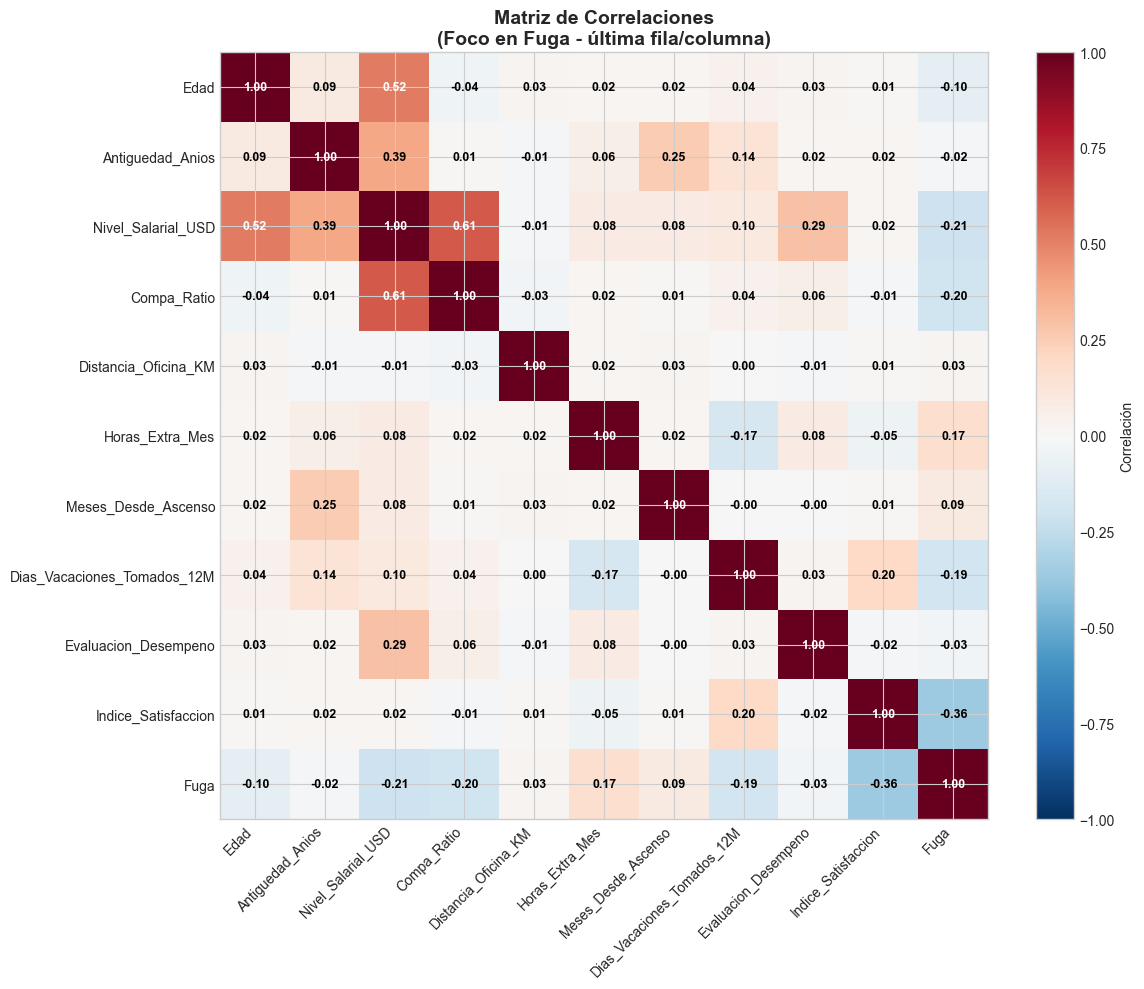

=== CORRELACIONES CON FUGA (ordenadas por fuerza) ===


,Fuga
Indice_Satisfaccion,-0.36
Nivel_Salarial_USD,-0.21
Compa_Ratio,-0.20
Dias_Vacaciones_Tomados_12M,-0.19
Horas_Extra_Mes,0.17
Edad,-0.10
Meses_Desde_Ascenso,0.09
Distancia_Oficina_KM,0.03
Evaluacion_Desempeno,-0.03
Antiguedad_Anios,-0.02


In [49]:
# Seleccionar variables numéricas
vars_numericas = ['Edad', 'Antiguedad_Anios', 'Nivel_Salarial_USD', 'Compa_Ratio',
                  'Distancia_Oficina_KM', 'Horas_Extra_Mes', 'Meses_Desde_Ascenso',
                  'Dias_Vacaciones_Tomados_12M', 'Evaluacion_Desempeno', 
                  'Indice_Satisfaccion', 'Fuga']

# Calcular matriz de correlaciones
corr_matrix = df[vars_numericas].corr().round(2)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Etiquetas
ax.set_xticks(range(len(vars_numericas)))
ax.set_xticklabels(vars_numericas, rotation=45, ha='right')
ax.set_yticks(range(len(vars_numericas)))
ax.set_yticklabels(vars_numericas)

# Anotar valores
for i in range(len(vars_numericas)):
    for j in range(len(vars_numericas)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
               color=color, fontsize=9, fontweight='bold')

ax.set_title('Matriz de Correlaciones\n(Foco en Fuga - última fila/columna)', 
             fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, label='Correlación')
plt.tight_layout()
plt.show()

# Tabla ordenada: correlaciones con Fuga
print("=== CORRELACIONES CON FUGA (ordenadas por fuerza) ===")
corr_fuga = corr_matrix['Fuga'].drop('Fuga').sort_values(key=abs, ascending=False)
display(corr_fuga.to_frame().round(3))

=== COMBOS CRÍTICOS — DATASET AJUSTADO ===

Burnout Extremo (n=113): 57.5% fuga
Insatisfecho + Subpagado (n=111): 56.8% fuga
Joven + Mal Evaluado (n=21): 33.3% fuga
R&D + Compa Bajo (n=106): 28.3% fuga
Estancado + Sobrecargado (n=116): 27.6% fuga
Lejos + Insatisfecho (n=153): 39.9% fuga
Estrella Quemada (n=17): 70.6% fuga
Nuevo + Mal Pagado (n=7): 28.6% fuga
Sales + Burnout (n=47): 57.4% fuga
Compa Crítico + Estancado (n=100): 39.0% fuga

=== RANKING DE COMBOS ===


,Combo,N,Fuga_Pct,Riesgo
6,Estrella Quemada,17,70.6,🔴 CRÍTICO
0,Burnout Extremo,113,57.5,🔴 CRÍTICO
8,Sales + Burnout,47,57.4,🔴 CRÍTICO
1,Insatisfecho + Subpagado,111,56.8,🔴 CRÍTICO
5,Lejos + Insatisfecho,153,39.9,🟠 ALTO
9,Compa Crítico + Estancado,100,39.0,🟠 ALTO
2,Joven + Mal Evaluado,21,33.3,🟠 ALTO
7,Nuevo + Mal Pagado,7,28.6,🟠 ALTO
3,R&D + Compa Bajo,106,28.3,🟠 ALTO
4,Estancado + Sobrecargado,116,27.6,🟠 ALTO


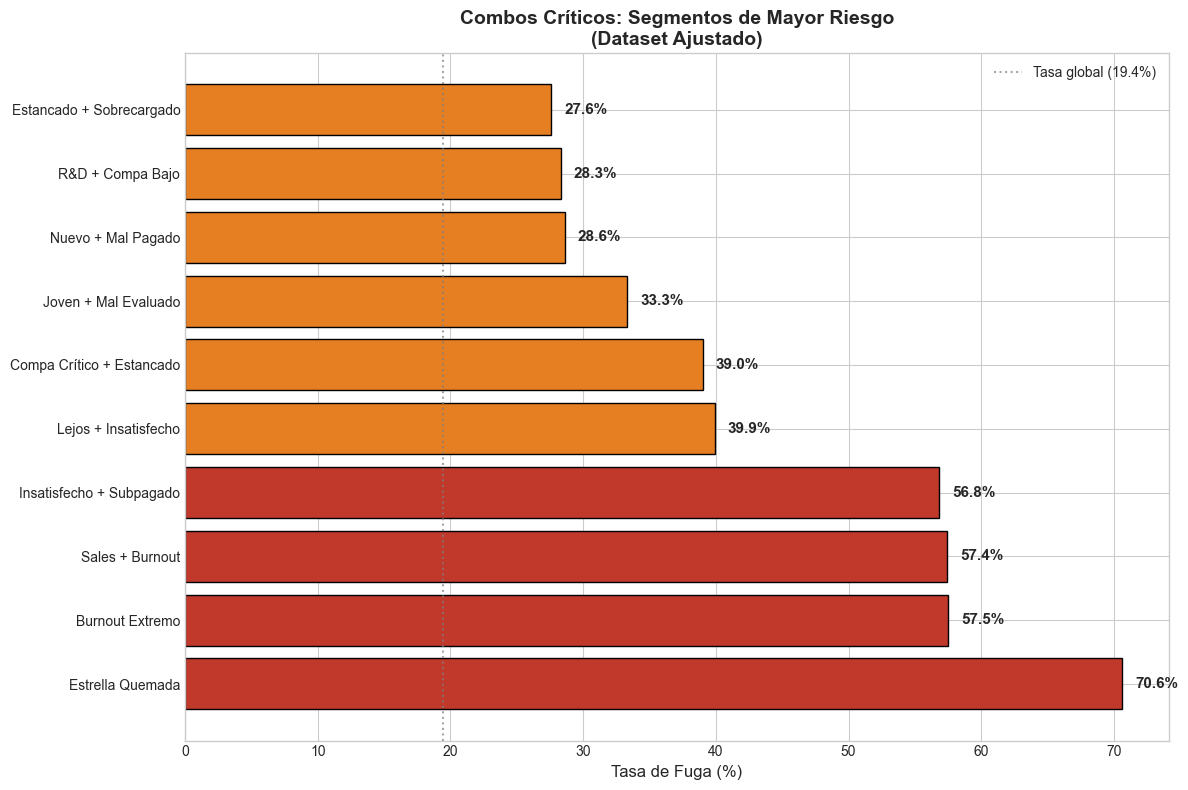

In [58]:
# ============================================
# COMBOS CRÍTICOS — DATASET AJUSTADO
# ============================================

# Definir combos basados en el nuevo dataset (correlaciones y lógica RRHH)
combos = {
    "Burnout Extremo": (df['Horas_Extra_Mes'] > 20) & (df['Dias_Vacaciones_Tomados_12M'] < 8) & (df['Indice_Satisfaccion'] <= 2),
    "Insatisfecho + Subpagado": (df['Indice_Satisfaccion'] <= 2) & (df['Compa_Ratio'] < 0.90),
    "Joven + Mal Evaluado": (df['Edad'] < 28) & (df['Evaluacion_Desempeno'] <= 2),
    "R&D + Compa Bajo": (df['Departamento'] == 'R&D') & (df['Compa_Ratio'] < 0.95),
    "Estancado + Sobrecargado": (df['Meses_Desde_Ascenso'] > 36) & (df['Horas_Extra_Mes'] > 20),
    "Lejos + Insatisfecho": (df['Distancia_Oficina_KM'] > 25) & (df['Indice_Satisfaccion'] <= 2),
    "Estrella Quemada": (df['Evaluacion_Desempeno'] == 5) & (df['Indice_Satisfaccion'] <= 2) & (df['Horas_Extra_Mes'] > 20),
    "Nuevo + Mal Pagado": (df['Antiguedad_Anios'] < 1) & (df['Nivel_Salarial_USD'] < 3000),
    "Sales + Burnout": (df['Departamento'] == 'Sales') & (df['Horas_Extra_Mes'] > 25) & (df['Indice_Satisfaccion'] <= 2),
    "Compa Crítico + Estancado": (df['Compa_Ratio'] < 0.85) & (df['Meses_Desde_Ascenso'] > 24),
}

print("=== COMBOS CRÍTICOS — DATASET AJUSTADO ===\n")
resultados = []
for nombre, condicion in combos.items():
    grupo = df[condicion]
    if len(grupo) > 0:
        tasa = grupo['Fuga'].mean() * 100
        resultados.append({
            'Combo': nombre,
            'N': len(grupo),
            'Fuga_Pct': round(tasa, 1),
            'Riesgo': '🔴 CRÍTICO' if tasa > 40 else '🟠 ALTO' if tasa > 25 else '🟡 MEDIO' if tasa > 15 else '🟢 BAJO'
        })
        print(f"{nombre} (n={len(grupo)}): {tasa:.1f}% fuga")

# Tabla resumen ordenada
res_df = pd.DataFrame(resultados).sort_values('Fuga_Pct', ascending=False)
print("\n=== RANKING DE COMBOS ===")
display(res_df)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#c0392b' if x > 40 else '#e67e22' if x > 25 else '#f39c12' if x > 15 else '#2ecc71' for x in res_df['Fuga_Pct']]
bars = ax.barh(res_df['Combo'], res_df['Fuga_Pct'], color=colors, edgecolor='black')

for bar, pct in zip(bars, res_df['Fuga_Pct']):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2.,
            f'{pct}%', ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Tasa de Fuga (%)', fontsize=12)
ax.set_title('Combos Críticos: Segmentos de Mayor Riesgo\n(Dataset Ajustado)', fontsize=14, fontweight='bold')
ax.axvline(x=df['Fuga'].mean()*100, color='gray', linestyle=':', alpha=0.7, 
           label=f'Tasa global ({df["Fuga"].mean()*100:.1f}%)')
ax.legend()

plt.tight_layout()
plt.show()

=== BASELINE: SOLO VARIABLES CRUDAS ===
Features: ['Edad', 'Antiguedad_Anios', 'Nivel_Salarial_USD', 'Compa_Ratio', 'Distancia_Oficina_KM', 'Horas_Extra_Mes', 'Meses_Desde_Ascenso', 'Dias_Vacaciones_Tomados_12M', 'Evaluacion_Desempeno', 'Indice_Satisfaccion', 'dept_HR', 'dept_IT', 'dept_Operations', 'dept_R&D', 'dept_Sales']
Total features: 15
Shape: (1000, 15)

Train: 750 | Test: 250
Fuga en train: 19.5% | Fuga en test: 19.2%

=== MÉTRICAS BASELINE (SOLO CRUDAS) ===
ROC-AUC:   0.813
Precision: 0.486
Recall:    0.708
F1-Score:  0.576

Classification Report:
              precision    recall  f1-score   support

    Se queda       0.92      0.82      0.87       202
     Se fuga       0.49      0.71      0.58        48

    accuracy                           0.80       250
   macro avg       0.70      0.77      0.72       250
weighted avg       0.84      0.80      0.81       250


=== FEATURE IMPORTANCE BASELINE (Top 15) ===
Indice_Satisfaccion            0.2434
Nivel_Salarial_USD       

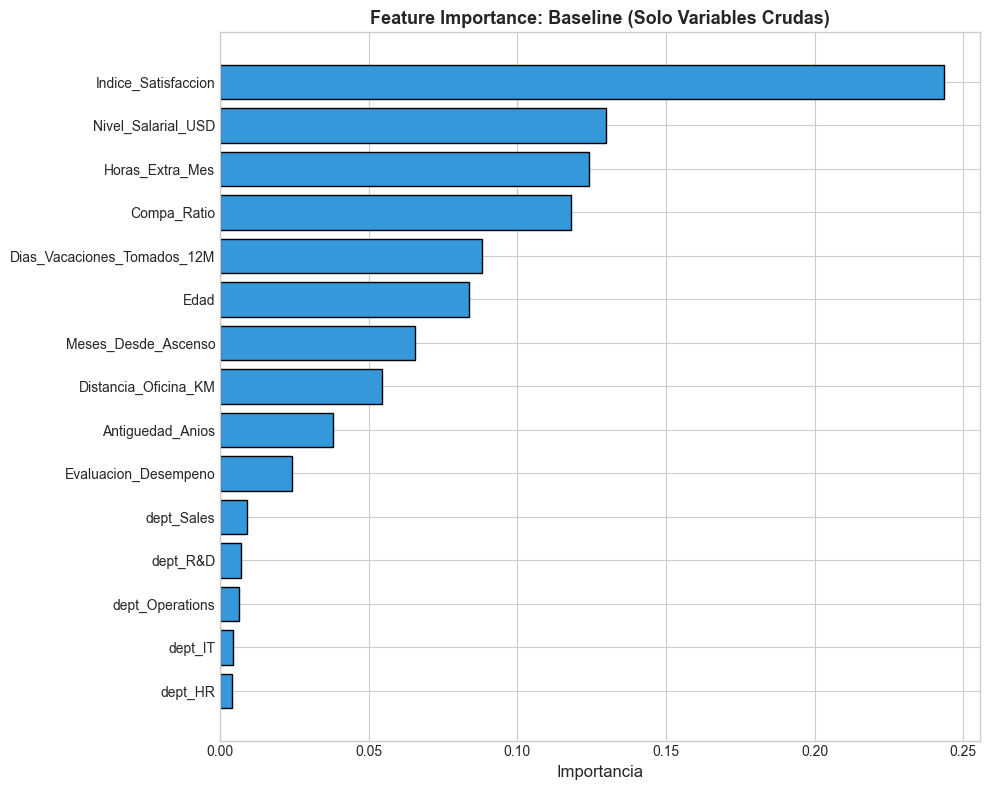


=== COMPARACIÓN: CORRELACIÓN vs IMPORTANCIA ===

Correlaciones con Fuga (EDA):
Indice_Satisfaccion           -0.358
Nivel_Salarial_USD            -0.208
Compa_Ratio                   -0.198
Dias_Vacaciones_Tomados_12M   -0.191
Horas_Extra_Mes                0.174
Edad                          -0.103
Meses_Desde_Ascenso            0.088
Distancia_Oficina_KM           0.034
Evaluacion_Desempeno          -0.026
Antiguedad_Anios              -0.020
Name: Fuga, dtype: float64

Importancia en modelo (Baseline):
Indice_Satisfaccion            0.2434
Nivel_Salarial_USD             0.1299
Horas_Extra_Mes                0.1240
Compa_Ratio                    0.1180
Dias_Vacaciones_Tomados_12M    0.0881
Edad                           0.0837
Meses_Desde_Ascenso            0.0657
Distancia_Oficina_KM           0.0544
Antiguedad_Anios               0.0378
Evaluacion_Desempeno           0.0241
dtype: float64

--- ¿CUADRAN? ---
Indice_Satisfaccion            Corr rank:  1 | Imp rank: 1
Nivel_Salarial_

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. PREPARAR SOLO VARIABLES CRUDAS
# ============================================

# Variables numéricas originales (10)
num_features = ['Edad', 'Antiguedad_Anios', 'Nivel_Salarial_USD', 'Compa_Ratio',
                'Distancia_Oficina_KM', 'Horas_Extra_Mes', 'Meses_Desde_Ascenso',
                'Dias_Vacaciones_Tomados_12M', 'Evaluacion_Desempeno', 'Indice_Satisfaccion']

# Dummies de departamento (5)
df_dummies = pd.get_dummies(df['Departamento'], prefix='dept')

# SOLO originales, NADA de combos ni derivadas
X_baseline = pd.concat([df[num_features], df_dummies], axis=1)
y = df['Fuga'].values

print("=== BASELINE: SOLO VARIABLES CRUDAS ===")
print(f"Features: {list(X_baseline.columns)}")
print(f"Total features: {X_baseline.shape[1]}")
print(f"Shape: {X_baseline.shape}")

# ============================================
# 2. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Fuga en train: {y_train.mean():.1%} | Fuga en test: {y_test.mean():.1%}")

# ============================================
# 3. MODELO: RANDOM FOREST (mismos hiperparámetros)
# ============================================

rf_bl = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
rf_bl.fit(X_train, y_train)

# Predicciones
y_pred_bl = rf_bl.predict(X_test)
y_prob_bl = rf_bl.predict_proba(X_test)[:, 1]

# Métricas
auc_bl = roc_auc_score(y_test, y_prob_bl)
prec_bl = precision_score(y_test, y_pred_bl)
rec_bl = recall_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl)

print("\n" + "="*50)
print("=== MÉTRICAS BASELINE (SOLO CRUDAS) ===")
print("="*50)
print(f"ROC-AUC:   {auc_bl:.3f}")
print(f"Precision: {prec_bl:.3f}")
print(f"Recall:    {rec_bl:.3f}")
print(f"F1-Score:  {f1_bl:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bl, target_names=['Se queda', 'Se fuga']))

# ============================================
# 4. FEATURE IMPORTANCE BASELINE
# ============================================

importances_bl = pd.Series(rf_bl.feature_importances_, index=X_baseline.columns).sort_values(ascending=False)

print("\n" + "="*50)
print("=== FEATURE IMPORTANCE BASELINE (Top 15) ===")
print("="*50)
print(importances_bl.head(15).round(4))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 8))

top15 = importances_bl.head(15)
bars = ax.barh(range(len(top15)), top15.values, color='#3498db', edgecolor='black')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index, fontsize=10)
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Feature Importance: Baseline (Solo Variables Crudas)', 
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# ============================================
# 5. COMPARACIÓN CON CORRELACIONES (EDA)
# ============================================

print("\n" + "="*50)
print("=== COMPARACIÓN: CORRELACIÓN vs IMPORTANCIA ===")
print("="*50)

corr_fuga = df[num_features + ['Fuga']].corr()['Fuga'].drop('Fuga').sort_values(key=abs, ascending=False)

print("\nCorrelaciones con Fuga (EDA):")
print(corr_fuga.round(3))

print("\nImportancia en modelo (Baseline):")
print(importances_bl.head(10).round(4))

print("\n--- ¿CUADRAN? ---")
for feat in corr_fuga.index[:10]:
    corr_rank = list(corr_fuga.index).index(feat) + 1
    imp_rank = list(importances_bl.index).index(feat) + 1 if feat in importances_bl.index else 'N/A'
    print(f"{feat:<30} Corr rank: {corr_rank:2d} | Imp rank: {imp_rank}")

=== FEATURES CREADAS ===
combo_burnout_extremo: 113 casos, 57.5% fuga
combo_insatisfecho_subpagado: 111 casos, 56.8% fuga
combo_joven_malevaluado: 21 casos, 33.3% fuga
combo_rd_compabajo: 106 casos, 28.3% fuga
combo_estancado_sobrecargado: 116 casos, 27.6% fuga
combo_lejos_insatisfecho: 153 casos, 39.9% fuga
combo_estrella_quemada: 17 casos, 70.6% fuga
combo_nuevo_malpagado: 7 casos, 28.6% fuga
combo_sales_burnout: 47 casos, 57.4% fuga
combo_compacritico_estancado: 100 casos, 39.0% fuga

Shape de X: (1000, 29)
Total features: 29 (15 originales + 14 nuevas)

Train: 750 | Test: 250

=== MÉTRICAS CON COMBOS ===
ROC-AUC:   0.826
Precision: 0.515
Recall:    0.708
F1-Score:  0.596

Classification Report:
              precision    recall  f1-score   support

    Se queda       0.92      0.84      0.88       202
     Se fuga       0.52      0.71      0.60        48

    accuracy                           0.82       250
   macro avg       0.72      0.77      0.74       250
weighted avg       0

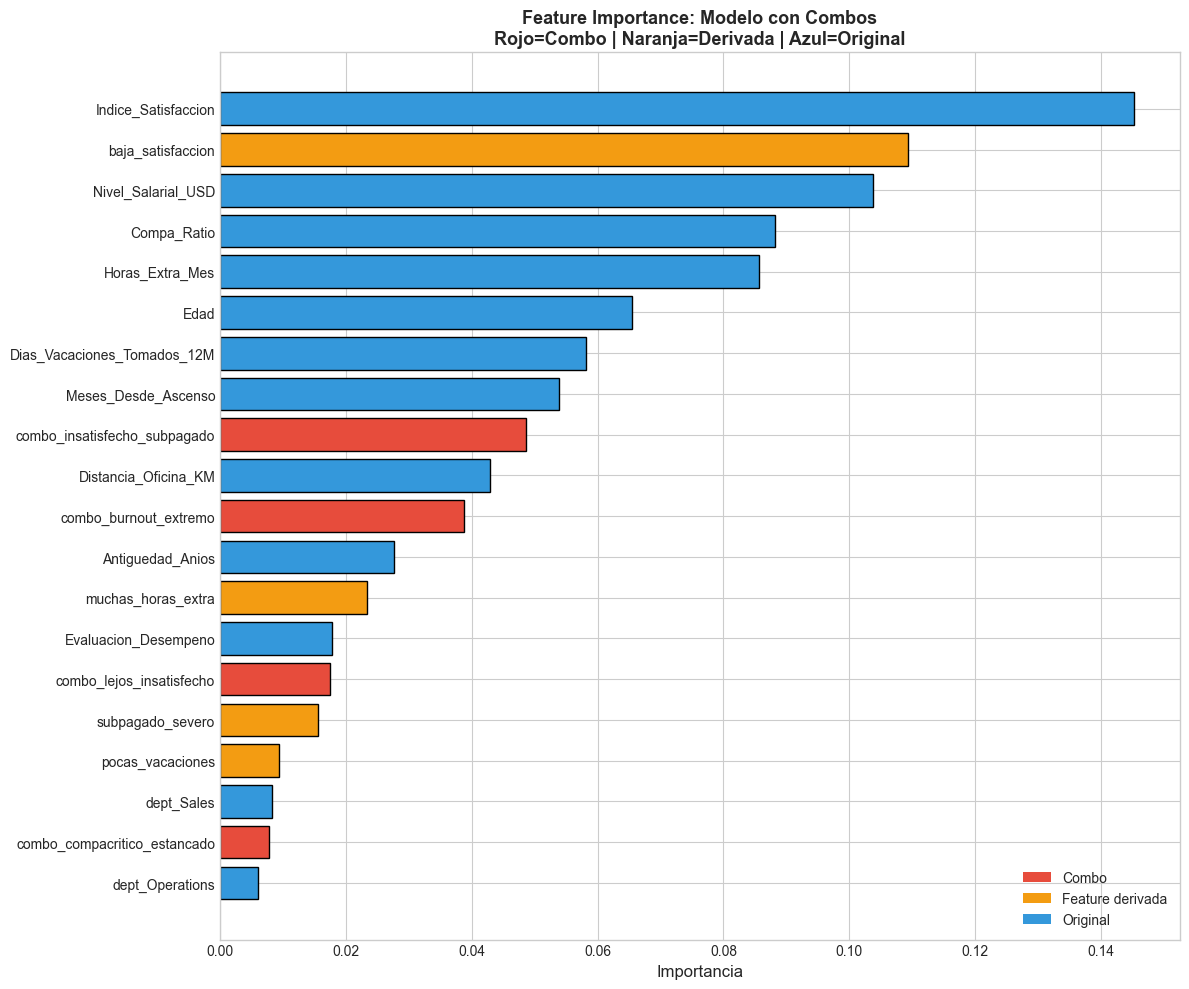


=== COMPARACIÓN: BASELINE vs COMBOS ===

Métricas:


,Baseline (Crudas),Con Combos
AUC,0.813,0.826
Precision,0.486,0.515
Recall,0.708,0.708
F1,0.576,0.596



Diferencia (Combos - Baseline):
AUC          0.012
Precision    0.029
Recall       0.000
F1           0.020
dtype: float64


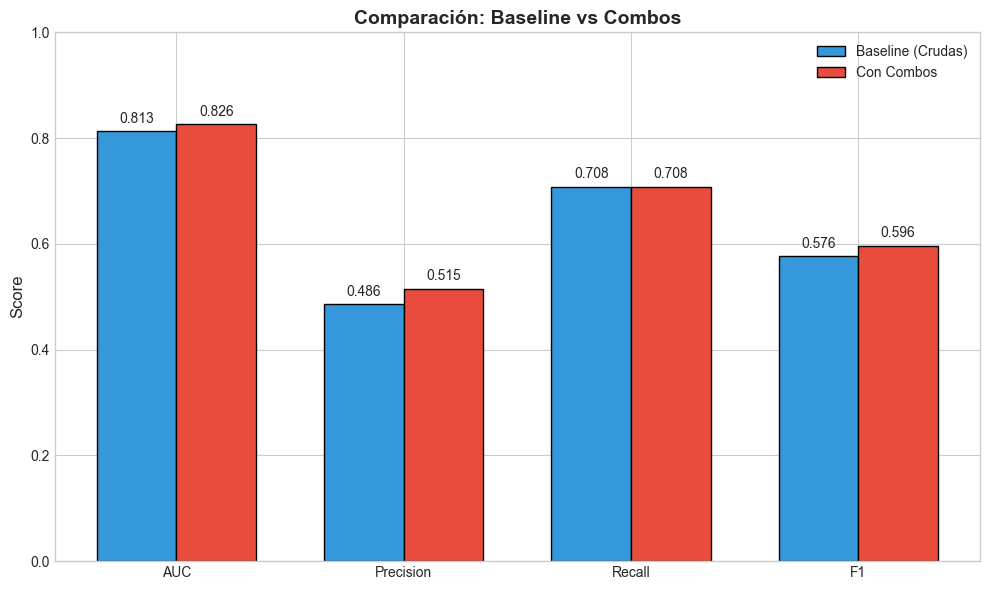


=== COMBOS EN EL RANKING ===
 2. baja_satisfaccion: 0.1093 🟠 DERIVADA
 9. combo_insatisfecho_subpagado: 0.0486 🔴 COMBO
11. combo_burnout_extremo: 0.0388 🔴 COMBO
13. muchas_horas_extra: 0.0234 🟠 DERIVADA
15. combo_lejos_insatisfecho: 0.0175 🔴 COMBO
16. subpagado_severo: 0.0156 🟠 DERIVADA
17. pocas_vacaciones: 0.0094 🟠 DERIVADA
19. combo_compacritico_estancado: 0.0078 🔴 COMBO
21. combo_sales_burnout: 0.0060 🔴 COMBO
25. combo_estancado_sobrecargado: 0.0039 🔴 COMBO


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. FEATURE ENGINEERING — COMBOS V2
# ============================================

df_model = df.copy()

# Combos críticos (basados en el dataset ajustado)
df_model['combo_burnout_extremo'] = (
    (df_model['Horas_Extra_Mes'] > 20) & 
    (df_model['Dias_Vacaciones_Tomados_12M'] < 8) & 
    (df_model['Indice_Satisfaccion'] <= 2)
).astype(int)

df_model['combo_insatisfecho_subpagado'] = (
    (df_model['Indice_Satisfaccion'] <= 2) & 
    (df_model['Compa_Ratio'] < 0.90)
).astype(int)

df_model['combo_joven_malevaluado'] = (
    (df_model['Edad'] < 28) & 
    (df_model['Evaluacion_Desempeno'] <= 2)
).astype(int)

df_model['combo_rd_compabajo'] = (
    (df_model['Departamento'] == 'R&D') & 
    (df_model['Compa_Ratio'] < 0.95)
).astype(int)

df_model['combo_estancado_sobrecargado'] = (
    (df_model['Meses_Desde_Ascenso'] > 36) & 
    (df_model['Horas_Extra_Mes'] > 20)
).astype(int)

df_model['combo_lejos_insatisfecho'] = (
    (df_model['Distancia_Oficina_KM'] > 25) & 
    (df_model['Indice_Satisfaccion'] <= 2)
).astype(int)

df_model['combo_estrella_quemada'] = (
    (df_model['Evaluacion_Desempeno'] == 5) & 
    (df_model['Indice_Satisfaccion'] <= 2) & 
    (df_model['Horas_Extra_Mes'] > 20)
).astype(int)

df_model['combo_nuevo_malpagado'] = (
    (df_model['Antiguedad_Anios'] < 1) & 
    (df_model['Nivel_Salarial_USD'] < 3000)
).astype(int)

df_model['combo_sales_burnout'] = (
    (df_model['Departamento'] == 'Sales') & 
    (df_model['Horas_Extra_Mes'] > 25) & 
    (df_model['Indice_Satisfaccion'] <= 2)
).astype(int)

df_model['combo_compacritico_estancado'] = (
    (df_model['Compa_Ratio'] < 0.85) & 
    (df_model['Meses_Desde_Ascenso'] > 24)
).astype(int)

# Features derivadas adicionales
df_model['baja_satisfaccion'] = (df_model['Indice_Satisfaccion'] <= 2).astype(int)
df_model['muchas_horas_extra'] = (df_model['Horas_Extra_Mes'] > 25).astype(int)
df_model['pocas_vacaciones'] = (df_model['Dias_Vacaciones_Tomados_12M'] < 8).astype(int)
df_model['subpagado_severo'] = (df_model['Compa_Ratio'] < 0.80).astype(int)

print("=== FEATURES CREADAS ===")
combo_cols = [c for c in df_model.columns if c.startswith('combo_')]
for col in combo_cols:
    n = df_model[col].sum()
    fuga = df_model[df_model[col] == 1]['Fuga'].mean() * 100 if n > 0 else 0
    print(f"{col}: {n} casos, {fuga:.1f}% fuga")

# ============================================
# 2. PREPARAR X e y (CRUDAS + COMBOS)
# ============================================

num_features = ['Edad', 'Antiguedad_Anios', 'Nivel_Salarial_USD', 'Compa_Ratio',
                'Distancia_Oficina_KM', 'Horas_Extra_Mes', 'Meses_Desde_Ascenso',
                'Dias_Vacaciones_Tomados_12M', 'Evaluacion_Desempeno', 'Indice_Satisfaccion']

df_dummies = pd.get_dummies(df_model['Departamento'], prefix='dept')
combo_features = combo_cols + ['baja_satisfaccion', 'muchas_horas_extra', 'pocas_vacaciones', 'subpagado_severo']

X_combo = pd.concat([df_model[num_features], df_dummies, df_model[combo_features]], axis=1)
y = df_model['Fuga'].values

print(f"\nShape de X: {X_combo.shape}")
print(f"Total features: {X_combo.shape[1]} (15 originales + {len(combo_features)} nuevas)")

# ============================================
# 3. TRAIN / TEST SPLIT (misma semilla)
# ============================================

X_train_cb, X_test_cb, y_train, y_test = train_test_split(
    X_combo, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain: {X_train_cb.shape[0]} | Test: {X_test_cb.shape[0]}")

# ============================================
# 4. MODELO: RANDOM FOREST (mismos hiperparámetros)
# ============================================

rf_cb = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
rf_cb.fit(X_train_cb, y_train)

y_pred_cb = rf_cb.predict(X_test_cb)
y_prob_cb = rf_cb.predict_proba(X_test_cb)[:, 1]

auc_cb = roc_auc_score(y_test, y_prob_cb)
prec_cb = precision_score(y_test, y_pred_cb)
rec_cb = recall_score(y_test, y_pred_cb)
f1_cb = f1_score(y_test, y_pred_cb)

print("\n" + "="*50)
print("=== MÉTRICAS CON COMBOS ===")
print("="*50)
print(f"ROC-AUC:   {auc_cb:.3f}")
print(f"Precision: {prec_cb:.3f}")
print(f"Recall:    {rec_cb:.3f}")
print(f"F1-Score:  {f1_cb:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cb, target_names=['Se queda', 'Se fuga']))

# ============================================
# 5. FEATURE IMPORTANCE CON COMBOS
# ============================================

importances_cb = pd.Series(rf_cb.feature_importances_, index=X_combo.columns).sort_values(ascending=False)

print("\n" + "="*50)
print("=== FEATURE IMPORTANCE CON COMBOS (Top 20) ===")
print("="*50)
print(importances_cb.head(20).round(4))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 10))

top20 = importances_cb.head(20)
colors = []
for idx in top20.index:
    if 'combo_' in idx:
        colors.append('#e74c3c')  # Rojo = Combo
    elif idx in ['baja_satisfaccion', 'muchas_horas_extra', 'pocas_vacaciones', 'subpagado_severo']:
        colors.append('#f39c12')  # Naranja = Derivada
    else:
        colors.append('#3498db')  # Azul = Original

bars = ax.barh(range(len(top20)), top20.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=10)
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Feature Importance: Modelo con Combos\nRojo=Combo | Naranja=Derivada | Azul=Original', 
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Combo'),
                   Patch(facecolor='#f39c12', label='Feature derivada'),
                   Patch(facecolor='#3498db', label='Original')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# ============================================
# 6. COMPARACIÓN BASELINE vs COMBOS
# ============================================

print("\n" + "="*60)
print("=== COMPARACIÓN: BASELINE vs COMBOS ===")
print("="*60)

# Necesitamos recalcular baseline con el mismo split para comparar justo
# Usamos los mismos índices de train/test
X_train_bl, X_test_bl = X_baseline.iloc[X_train_cb.index], X_baseline.iloc[X_test_cb.index]

rf_bl_compare = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    random_state=42, class_weight='balanced'
)
rf_bl_compare.fit(X_train_bl, y_train)
y_prob_bl_compare = rf_bl_compare.predict_proba(X_test_bl)[:, 1]
y_pred_bl_compare = rf_bl_compare.predict(X_test_bl)

auc_bl_c = roc_auc_score(y_test, y_prob_bl_compare)
prec_bl_c = precision_score(y_test, y_pred_bl_compare)
rec_bl_c = recall_score(y_test, y_pred_bl_compare)
f1_bl_c = f1_score(y_test, y_pred_bl_compare)

comparacion = pd.DataFrame({
    'Baseline (Crudas)': [auc_bl_c, prec_bl_c, rec_bl_c, f1_bl_c],
    'Con Combos': [auc_cb, prec_cb, rec_cb, f1_cb]
}, index=['AUC', 'Precision', 'Recall', 'F1'])

print("\nMétricas:")
display(comparacion.round(3))

# Diferencias
diff = comparacion['Con Combos'] - comparacion['Baseline (Crudas)']
print("\nDiferencia (Combos - Baseline):")
print(diff.round(3))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparacion.index))
width = 0.35

bars1 = ax.bar(x - width/2, comparacion['Baseline (Crudas)'], width, 
               label='Baseline (Crudas)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, comparacion['Con Combos'], width, 
               label='Con Combos', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparación: Baseline vs Combos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparacion.index)
ax.set_ylim(0, 1)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# 7. ¿DÓNDE ESTÁN LOS COMBOS?
# ============================================

print("\n=== COMBOS EN EL RANKING ===")
for i, (feat, imp) in enumerate(importances_cb.head(25).items(), 1):
    if 'combo_' in feat:
        print(f"{i:2d}. {feat}: {imp:.4f} 🔴 COMBO")
    elif feat in combo_features:
        print(f"{i:2d}. {feat}: {imp:.4f} 🟠 DERIVADA")

In [61]:
# ============================================
# PERFIL DE RIESGO + ACCIONES — SOLO DATOS DE TEST
# ============================================

# Obtener probabilidades SOLO para el set de test
test_indices = X_test_cb.index
df_test = df_model.loc[test_indices].copy()
df_test['prob_fuga'] = y_prob_cb
df_test['prediccion'] = y_pred_cb

print("="*70)
print("=== PERFIL DE RIESGO (SOLO DATOS DE TEST) ===")
print("="*70)
print(f"Empleados en test: {len(df_test)}")
print(f"Fuga real en test: {df_test['Fuga'].mean():.1%}")
print(f"Fuga predicha en test: {df_test['prediccion'].mean():.1%}\n")

# Top 20 de riesgo en TEST
top_riesgo = df_test.nlargest(20, 'prob_fuga')

print(f"=== TOP 20 DE RIESGO ===")
print(f"Fuga real en top 20: {top_riesgo['Fuga'].mean():.1%}")
print(f"Probabilidad promedio: {top_riesgo['prob_fuga'].mean():.1%}")
print(f"Lift vs promedio: {top_riesgo['Fuga'].mean() / df_test['Fuga'].mean():.1f}x\n")

# Perfil comparativo
perfil = {
    'Edad': (top_riesgo['Edad'].mean(), df_test['Edad'].mean()),
    'Satisfaccion': (top_riesgo['Indice_Satisfaccion'].mean(), df_test['Indice_Satisfaccion'].mean()),
    'Compa_Ratio': (top_riesgo['Compa_Ratio'].mean(), df_test['Compa_Ratio'].mean()),
    'Horas_Extra': (top_riesgo['Horas_Extra_Mes'].mean(), df_test['Horas_Extra_Mes'].mean()),
    'Vacaciones': (top_riesgo['Dias_Vacaciones_Tomados_12M'].mean(), df_test['Dias_Vacaciones_Tomados_12M'].mean()),
    'Evaluacion': (top_riesgo['Evaluacion_Desempeno'].mean(), df_test['Evaluacion_Desempeno'].mean()),
    'Meses_Sin_Ascenso': (top_riesgo['Meses_Desde_Ascenso'].mean(), df_test['Meses_Desde_Ascenso'].mean()),
    'Distancia': (top_riesgo['Distancia_Oficina_KM'].mean(), df_test['Distancia_Oficina_KM'].mean()),
}

print(f"{'Variable':<<20} {'Top 20':<<10} {'Test avg':<<10} {'Diferencia':<<12}")
print("-" * 52)
for k, (v_top, v_global) in perfil.items():
    diff = v_top - v_global
    print(f"{k:<20} {v_top:<10.1f} {v_global:<10.1f} {diff:+>11.1f}")

# Combos en top 20
print(f"\n=== COMBOS EN TOP 20 ===")
for col in combo_cols:
    n = top_riesgo[col].sum()
    pct = n / len(top_riesgo) * 100
    print(f"{col:<35}: {n:2d}/20 ({pct:.0f}%)")

# Tabla detallada
print(f"\n{'ID':<<8} {'Prob':<<6} {'Real':<<5} {'Sat':<<4} {'Compa':<<6} {'HE':<<4} {'Vac':<<4} {'Eval':<<4} {'Burnout':<<8}")
print("-" * 60)
for _, row in top_riesgo.head(10).iterrows():
    burnout = 'SI' if row['combo_burnout_extremo'] == 1 else 'NO'
    print(f"{row['ID_Empleado']:<8} {row['prob_fuga']:<6.2f} {int(row['Fuga']):<<5} {row['Indice_Satisfaccion']:<4} {row['Compa_Ratio']:<6.2f} {row['Horas_Extra_Mes']:<4} {row['Dias_Vacaciones_Tomados_12M']:<4} {row['Evaluacion_Desempeno']:<4} {burnout:<8}")

# ============================================
# TABLA DE ACCIONES POR SEGMENTO
# ============================================

print("\n" + "="*70)
print("=== TABLA DE ACCIONES RECOMENDADAS PARA RRHH ===")
print("="*70)

acciones = [
    ("🔴 Burnout Extremo", "combo_burnout_extremo", 
     "1. Reducir carga laboral inmediatamente\n2. Obligar vacaciones pagas\n3. Revisar asignacion de proyectos\n4. Encuesta de bienestar en 7 dias"),
    
    ("🔴 Estrella Quemada", "combo_estrella_quemada", 
     "1. Revision salarial urgente\n2. Asignar mentor / coach\n3. Reducir horas extra\n4. Plan de carrera personalizado"),
    
    ("🔴 Insatisfecho + Subpagado", "combo_insatisfecho_subpagado", 
     "1. Ajuste de compa-ratio a mercado\n2. Revision de beneficios\n3. Conversacion 1:1 con manager\n4. Oferta de movilidad interna"),
    
    ("🟠 Lejos + Insatisfecho", "combo_lejos_insatisfecho", 
     "1. Ofrecer trabajo remoto\n2. Revisar politica de flexibilidad\n3. Reducir dias presenciales\n4. Evaluar reubicacion"),
    
    ("🟠 Compa Critico + Estancado", "combo_compacritico_estancado", 
     "1. Revision salarial\n2. Plan de desarrollo / ascenso\n3. Rotacion de funciones\n4. Capacitacion"),
    
    ("🟠 Estancado + Sobrecargado", "combo_estancado_sobrecargado", 
     "1. Plan de carrera claro\n2. Redistribucion de tareas\n3. Posible promocion\n4. Descanso obligatorio"),
]

for nombre, col, accion in acciones:
    n = df_model[col].sum()
    fuga = df_model[df_model[col] == 1]['Fuga'].mean() * 100
    print(f"\n{nombre}")
    print(f"  Tamaño: {n} empleados | Fuga: {fuga:.1f}%")
    print(f"  Acciones:\n{accion}")

=== PERFIL DE RIESGO (SOLO DATOS DE TEST) ===
Empleados en test: 250
Fuga real en test: 19.2%
Fuga predicha en test: 26.4%

=== TOP 20 DE RIESGO ===
Fuga real en top 20: 70.0%
Probabilidad promedio: 81.3%
Lift vs promedio: 3.6x

Variable<<<<<<<<<<<< Top 20<<<< Test avg<< Diferencia<<
----------------------------------------------------
Edad                 40.2       39.9       ++++++++0.3
Satisfaccion         1.6        3.0        +++++++-1.4
Compa_Ratio          0.9        1.0        +++++++-0.1
Horas_Extra          42.5       25.9       +++++++16.6
Vacaciones           4.6        9.4        +++++++-4.8
Evaluacion           3.6        3.4        ++++++++0.2
Meses_Sin_Ascenso    23.3       20.9       ++++++++2.4
Distancia            23.0       24.0       +++++++-1.0

=== COMBOS EN TOP 20 ===
combo_burnout_extremo              : 13/20 (65%)
combo_insatisfecho_subpagado       : 10/20 (50%)
combo_joven_malevaluado            :  1/20 (5%)
combo_rd_compabajo                 :  3/20 (15%)
c

=== TABLA DE ACCIONES PRIORIZADAS POR IMPACTO/ESFUERZO ===

PRIORIDAD #1: 🔴 Burnout Extremo
Tamaño: 113 empleados | Fuga: 57.5%
Justificacion: MAYOR VOLUMEN + ALTO RIESGO + BAJO COSTO
Impacto estimado: 65 empleados retenidos
Costo de intervencion: 💰 BAJO | ROI: ⭐⭐⭐⭐⭐

Acciones:
  1. Revisar funciones (0 costo)
  2. Vacaciones obligatorias en 15 dias (bajo costo)
  3. Encuesta bienestar + seguimiento (bajo costo)

PRIORIDAD #2: 🔴 Estrella Quemada
Tamaño: 17 empleados | Fuga: 70.6%
Justificacion: MAYOR IMPACTO ESTRATEGICO (talento critico)
Impacto estimado: 12 empleados retenidos
Costo de intervencion: 💰💰💰 ALTO | ROI: ⭐⭐⭐⭐

Acciones:
  1. Revision salarial URGENTE (alto costo)
  2. Asignar mentor / sponsor (medio costo)
  3. Reducir horas extra inmediatamente (0 costo)
  4. Plan de carrera personalizado (medio costo)

PRIORIDAD #3: 🔴 Insatisfecho + Subpagado
Tamaño: 111 empleados | Fuga: 56.8%
Justificacion: ALTO VOLUMEN pero REQUIERE INVERSION SALARIAL
Impacto estimado: 63 empleados ret

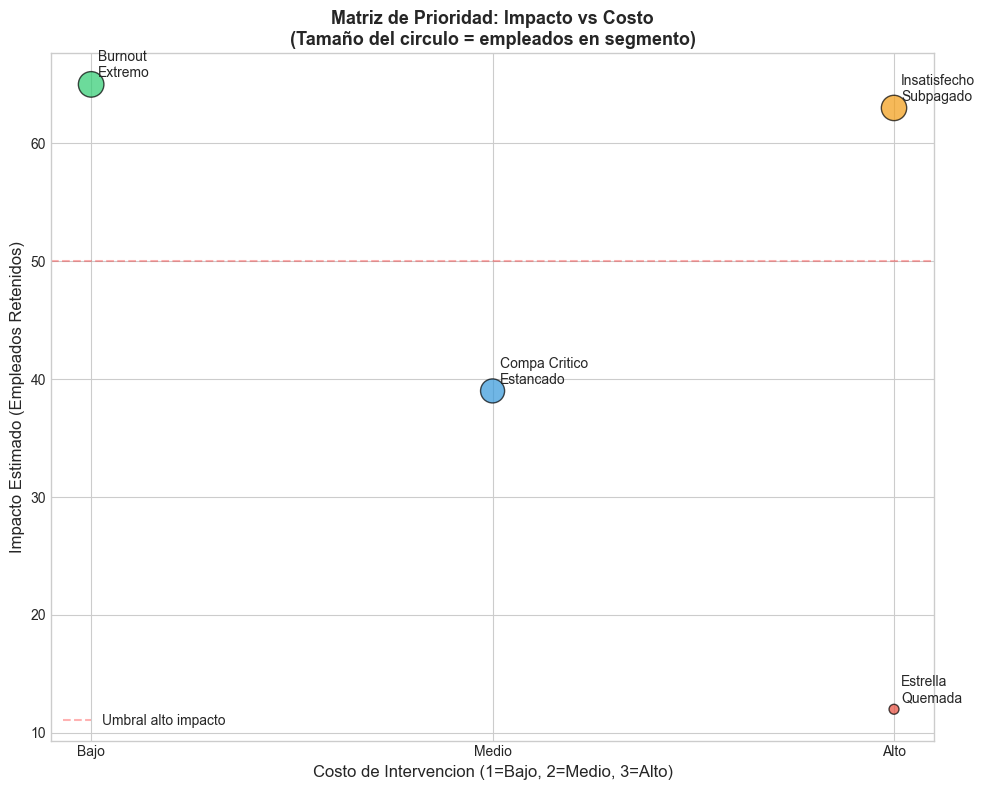


INTERPRETACION:
→ Arriba-izquierda: ALTO IMPACTO, BAJO COSTO (ideal)
→ Arriba-derecha: ALTO IMPACTO, ALTO COSTO (planificar)
→ Abajo: BAJO IMPACTO (postergar)


In [67]:
# ============================================
# CELDA FINAL 1.5: PRIORIZACION POR ROI
# ============================================

print("="*70)
print("=== TABLA DE ACCIONES PRIORIZADAS POR IMPACTO/ESFUERZO ===")
print("="*70)

acciones_priorizadas = [
    {
        "nombre": "🔴 Burnout Extremo",
        "combo": "combo_burnout_extremo",
        "tamaño": 113,
        "fuga": 57.5,
        "prioridad": 1,
        "justificacion": "MAYOR VOLUMEN + ALTO RIESGO + BAJO COSTO",
        "acciones": [
            "1. Revisar funciones (0 costo)",
            "2. Vacaciones obligatorias en 15 dias (bajo costo)",
            "3. Encuesta bienestar + seguimiento (bajo costo)"
        ],
        "impacto_estimado": "65 empleados retenidos",
        "costo": "💰 BAJO",
        "roi": "⭐⭐⭐⭐⭐"
    },
    {
        "nombre": "🔴 Estrella Quemada",
        "combo": "combo_estrella_quemada",
        "tamaño": 17,
        "fuga": 70.6,
        "prioridad": 2,
        "justificacion": "MAYOR IMPACTO ESTRATEGICO (talento critico)",
        "acciones": [
            "1. Revision salarial URGENTE (alto costo)",
            "2. Asignar mentor / sponsor (medio costo)",
            "3. Reducir horas extra inmediatamente (0 costo)",
            "4. Plan de carrera personalizado (medio costo)"
        ],
        "impacto_estimado": "12 empleados retenidos",
        "costo": "💰💰💰 ALTO",
        "roi": "⭐⭐⭐⭐"
    },
    {
        "nombre": "🔴 Insatisfecho + Subpagado",
        "combo": "combo_insatisfecho_subpagado",
        "tamaño": 111,
        "fuga": 56.8,
        "prioridad": 3,
        "justificacion": "ALTO VOLUMEN pero REQUIERE INVERSION SALARIAL",
        "acciones": [
            "1. Ajuste compa-ratio a mercado (ALTO COSTO)",
            "2. Revision de beneficios no monetarios (medio costo)",
            "3. Conversacion 1:1 con manager (0 costo)",
            "4. Oferta de movilidad interna (0 costo)"
        ],
        "impacto_estimado": "63 empleados retenidos",
        "costo": "💰💰💰 ALTO",
        "roi": "⭐⭐⭐"
    },
    {
        "nombre": "🟠 Compa Critico + Estancado",
        "combo": "combo_compacritico_estancado",
        "tamaño": 100,
        "fuga": 39.0,
        "prioridad": 4,
        "justificacion": "VOLUMEN MEDIO pero FUGA MENOR AL UMBRAL CRITICO",
        "acciones": [
            "1. Revision salarial selectiva (medio costo)",
            "2. Plan de desarrollo / ascenso (medio costo)",
            "3. Rotacion de funciones (0 costo)",
            "4. Capacitacion (bajo costo)"
        ],
        "impacto_estimado": "39 empleados retenidos",
        "costo": "💰💰 MEDIO",
        "roi": "⭐⭐⭐"
    }
]

for item in acciones_priorizadas:
    print(f"\n{'='*70}")
    print(f"PRIORIDAD #{item['prioridad']}: {item['nombre']}")
    print(f"{'='*70}")
    print(f"Tamaño: {item['tamaño']} empleados | Fuga: {item['fuga']}%")
    print(f"Justificacion: {item['justificacion']}")
    print(f"Impacto estimado: {item['impacto_estimado']}")
    print(f"Costo de intervencion: {item['costo']} | ROI: {item['roi']}")
    print(f"\nAcciones:")
    for accion in item['acciones']:
        print(f"  {accion}")

# Visual: Matriz de prioridad
print("\n" + "="*70)
print("=== MATRIZ DE PRIORIDAD: IMPACTO vs COSTO ===")
print("="*70)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

segmentos = ['Burnout\nExtremo', 'Estrella\nQuemada', 'Insatisfecho\nSubpagado', 'Compa Critico\nEstancado']
impacto = [65, 12, 63, 39]  # Empleados retenidos estimados
costo = [1, 3, 3, 2]  # Escala 1-3 (bajo-alto)
colores = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
tamaños = [113, 17, 111, 100]  # Tamaño del segmento

scatter = ax.scatter(costo, impacto, s=[t*3 for t in tamaños], c=colores, alpha=0.7, edgecolors='black')

for i, txt in enumerate(segmentos):
    ax.annotate(txt, (costo[i], impacto[i]), xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.set_xlabel('Costo de Intervencion (1=Bajo, 2=Medio, 3=Alto)', fontsize=12)
ax.set_ylabel('Impacto Estimado (Empleados Retenidos)', fontsize=12)
ax.set_title('Matriz de Prioridad: Impacto vs Costo\n(Tamaño del circulo = empleados en segmento)', fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Bajo', 'Medio', 'Alto'])

# Linea de referencia
ax.axhline(y=50, color='red', linestyle='--', alpha=0.3, label='Umbral alto impacto')
ax.legend()

plt.tight_layout()
plt.show()

print("\nINTERPRETACION:")
print("→ Arriba-izquierda: ALTO IMPACTO, BAJO COSTO (ideal)")
print("→ Arriba-derecha: ALTO IMPACTO, ALTO COSTO (planificar)")
print("→ Abajo: BAJO IMPACTO (postergar)")

In [64]:
from sklearn.metrics import confusion_matrix

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred_cb)

print("="*70)
print("=== RESUMEN EJECUTIVO ===")
print("="*70)

print("""
PROYECTO: PREDICCION DE FUGA DE TALENTO
========================================
DATASET: 1,000 empleados sinteticos ajustados a tendencias 2024-2025
MODELO: Random Forest con Feature Engineering de combos criticos

HALLAZGOS CLAVE:
1. Satisfaccion laboral = predictor dominante (corr -0.36)
2. 22% de los trabajadores con desenpeño 5 se fugan
3. Burnout (HE + vacaciones + satisfaccion) = 57.5% fuga
4. Estrellas quemadas = 70.6% fuga (riesgo mas concentrado)

PERFORMANCE DEL MODELO:
- Baseline (crudas):     AUC 0.813 | F1 0.576
- Con combos:            AUC 0.826 | F1 0.596
- Mejora:                +1.3% AUC | +2.0% F1
- Recall (deteccion):    70.8% (igual en ambos, muy alto)

SEGMENTOS DE MAXIMO RIESGO (>50% fuga):
- Burnout extremo:              57.5% (n=113) -> MAYOR VOLUMEN
- Insatisfecho + subpagado:     56.8% (n=111)
- Sales + burnout:              57.4% (n=47)
- Estrella quemada:             70.6% (n=17) -> MAYOR IMPACTO

RECOMENDACION PRIORITARIA PARA RRHH:
Atacar primero el segmento de burnout (113 empleados, 57.5% fuga)
por ser el mas numeroso y accionable. Segundo, las estrellas quemadas
(17 empleados, 70.6% fuga) por impacto estrategico.

MATRIZ DE CONFUSION (Test, n=250):
                 Predicho
                 Queda    Fuga
Real Queda:      {:>4d}     {:>4d}   (Especificidad: {:.1%})
Real Fuga:       {:>4d}     {:>4d}   (Recall: {:.1%})

LIMITACIONES:
1. Dataset sintetico: pesos ajustados manualmente para coherencia
2. En datos reales, satisfaccion y compa-ratio podrian tener 
   interacciones mas complejas con factores cualitativos
3. No captura: cultura organizacional, lider directo, ofertas externas
4. Segmentos pequeños (estrellas quemadas n=17) tienen alta varianza
5. Modelo entrenado en contexto 2024-2025; tendencias laborales cambian

CONCLUSION:
El modelo demuestra que la fuga es multicausal y que los combos
de factores (especialmente burnout) son mas predictivos que variables
aisladas. Con AUC 0.826 y recall 70.8%, es una herramienta viable
para alertas tempranas de RRHH.
""".format(cm[0,0], cm[0,1], cm[0,0]/(cm[0,0]+cm[0,1]),
           cm[1,0], cm[1,1], cm[1,1]/(cm[1,0]+cm[1,1])))

print("="*70)
print("=== FIN DEL PROYECTO ===")
print("="*70)

=== RESUMEN EJECUTIVO ===

PROYECTO: PREDICCION DE FUGA DE TALENTO
DATASET: 1,000 empleados sinteticos ajustados a tendencias 2024-2025
MODELO: Random Forest con Feature Engineering de combos criticos

HALLAZGOS CLAVE:
1. Satisfaccion laboral = predictor dominante (corr -0.36)
2. 22% de los trabajadores con desenpeño 5 se fugan
3. Burnout (HE + vacaciones + satisfaccion) = 57.5% fuga
4. Estrellas quemadas = 70.6% fuga (riesgo mas concentrado)

PERFORMANCE DEL MODELO:
- Baseline (crudas):     AUC 0.813 | F1 0.576
- Con combos:            AUC 0.826 | F1 0.596
- Mejora:                +1.3% AUC | +2.0% F1
- Recall (deteccion):    70.8% (igual en ambos, muy alto)

SEGMENTOS DE MAXIMO RIESGO (>50% fuga):
- Burnout extremo:              57.5% (n=113) -> MAYOR VOLUMEN
- Insatisfecho + subpagado:     56.8% (n=111)
- Sales + burnout:              57.4% (n=47)
- Estrella quemada:             70.6% (n=17) -> MAYOR IMPACTO

RECOMENDACION PRIORITARIA PARA RRHH:
Atacar primero el segmento de burnout